# Seasonal Agriculture Performance Analysis

**VOIS AICTE Batch1 2026-2027 &mdash; Major Project**

| | |
|---|---|
| **Student** | _[your name]_ |
| **College** | _[your college]_ |
| **AICTE STU ID** | _[from your offer letter]_ |
| **Dataset** | `seasonal_agriculture_performance_dataset.csv` &mdash; 4,000 farms x 28 attributes |

---

## The question this notebook answers

> **How and why does agricultural performance differ between the Kharif, Rabi and Zaid
> seasons, and what should be done about it?**

Indian agriculture runs on three cropping seasons. **Kharif** is the monsoon season
(sown Jun-Jul, harvested Oct-Nov) and is rain-fed by definition. **Rabi** is the winter
season (sown Oct-Nov, harvested Mar-Apr), cooler and dependent on residual soil moisture
and irrigation. **Zaid** is the short summer season between them (Mar-Jun), hot, dry and
almost entirely irrigation-dependent.

A farm's inputs &mdash; fertiliser, water, pesticide, seed, labour &mdash; are largely
decided by the farmer. Its environment is not. If performance differs sharply by season
while input spending does not, then the gap is an **allocation problem**, and that is
something policy and extension services can actually fix. That is the hypothesis this
notebook sets out to test.

**Scope discipline.** The project brief explicitly warns against "a generic analysis of
the entire dataset" and asks instead for a focused problem. This notebook therefore does
not tour all 28 columns in turn. Every section below exists to serve the seasonal
question above; columns are examined when and because they bear on it.

---

## Contents

| # | Section | Purpose |
|---|---------|---------|
| 0 | Setup | Environment, reproducibility, shared plotting style |
| 1 | Structural profile | What is in the file; map columns to the brief's six families |
| 2 | Integrity audit | Arithmetic identities, missingness mechanism, censoring, plausibility |
| 3 | Cleaning &amp; feature engineering | Principled repair; build the metrics the analysis needs |
| 4 | **Research questions** | The 10 specific questions this notebook answers |
| 5 | Univariate EDA | Distributions, skew, outlier policy |
| 6 | **Seasonal comparison** | The core section: how the three seasons differ |
| 7 | Relationships | Correlation, non-linearity, within-season interactions |
| 8 | Group comparisons | Crop, irrigation and geography inside each season |
| 9 | Significance testing | Formal tests with effect sizes |
| 10 | Drivers, conclusions &amp; recommendations | Model-based ranking, executive summary, limitations |

## 0. Setup

One cell fixes the entire notebook's environment: library imports, the random seed that
makes the modelling section reproducible, pandas display settings, and &mdash; importantly
for a report that will be read as a whole &mdash; a single plotting style plus a fixed
colour for each season, used identically in every figure from here on.

Figures are also written to `figures/` as PNGs so they can be reused in the project
presentation without re-running anything.

In [1]:
# --- Core stack -------------------------------------------------------------
import os, sys, warnings, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Reproducibility --------------------------------------------------------
SEED = 42
np.random.seed(SEED)

# --- Display ----------------------------------------------------------------
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# --- Shared plotting style (applies to every figure in this notebook) -------
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 10.5, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.labelsize": 10.5, "axes.edgecolor": "#4a4a4a", "axes.linewidth": 0.8,
    "grid.color": "#d9d9d9", "grid.linewidth": 0.6,
    "legend.frameon": True, "legend.framealpha": 0.9, "figure.autolayout": False,
})

# The three seasons, in their agronomic calendar order. Used as an ordered
# categorical throughout so every table and axis sorts identically.
SEASON_ORDER  = ["Kharif", "Rabi", "Zaid"]
SEASON_COLORS = {"Kharif": "#2f7d5d",   # monsoon green
                 "Rabi":   "#41689e",   # winter blue
                 "Zaid":   "#b06a1f"}   # summer amber
SEASON_PALETTE = [SEASON_COLORS[s] for s in SEASON_ORDER]

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
_fig_log = []

def savefig(fig, name):
    """Save a figure to figures/ and record it, so section 10 can list them all."""
    path = FIGDIR / f"{name}.png"
    fig.savefig(path)
    _fig_log.append(str(path))
    return path

def inr(x):
    """Format a number as Indian rupees for narrative print statements."""
    return f"Rs {x:,.0f}"

def ordinal(n):
    """1 -> 1st, 2 -> 2nd, 3 -> 3rd, 4 -> 4th. Used in the executive summary."""
    n = int(n)
    suffix = "th" if 11 <= n % 100 <= 13 else {1: "st", 2: "nd", 3: "rd"}.get(n % 10, "th")
    return f"{n}{suffix}"

print(f"python  {sys.version.split()[0]}")
print(f"pandas  {pd.__version__}   numpy {np.__version__}")
print(f"scipy   {stats.__name__.split('.')[0]} ok   seaborn {sns.__version__}")
print(f"seed    {SEED}  |  figures -> {FIGDIR.resolve()}")

python  3.12.12
pandas  2.2.2   numpy 1.26.4
scipy   scipy ok   seaborn 0.13.2
seed    42  |  figures -> /Users/aman/Downloads/All_DU_Project/vois/figures


The environment is fixed and reproducible. Every figure below uses the same season colours
&mdash; green for Kharif, blue for Rabi, amber for Zaid &mdash; so a reader can track a
season across the whole document without re-reading legends.

---

## 1. Structural profile

Before any analysis, establish what the file actually contains: its shape, its types, where
values are missing, and whether each row really is one distinct farm. The brief describes
the data as covering "farming practices, environmental conditions, crop production, resource
usage and economic performance", so the final step of this section maps all 28 columns onto
those families. That mapping is used to organise every table that follows.

The dataset is loaded next. Because this notebook is opened in several places
&mdash; locally, in Colab, on a marker's machine &mdash; a **compressed copy of the data is
embedded in the cell below**, and the loader falls back to it whenever the CSV file itself
cannot be found. The notebook therefore always runs, with no upload step required, while
still reading the real file whenever one is present.

In [2]:
#@title Embedded dataset (compressed fallback copy) - run me, no output expected

# ---------------------------------------------------------------------------
# A gzip-compressed, base64-encoded copy of the dataset, carried inside the
# notebook so it runs anywhere without a separate file: a fresh Colab session,
# a different machine, or an offline marker's laptop.
#
# This is a FALLBACK ONLY. The cell below prefers the real CSV whenever it can
# be found, and decodes this copy solely when it cannot. The decoded bytes are
# checksummed against the original, so a corrupted paste fails loudly rather
# than analysing silently wrong data.
# ---------------------------------------------------------------------------
import base64, gzip, hashlib, io as _io

_DATA_MD5 = "0f9ef0b74c777b6b828f561491bcf40b"

_DATA_B64 = (
    "..."
)


def load_embedded_dataset():
    '''Decode the embedded copy, verify its checksum, return it as a DataFrame.'''
    blob = gzip.decompress(base64.b64decode(_DATA_B64))
    digest = hashlib.md5(blob).hexdigest()
    if digest != _DATA_MD5:
        raise ValueError(
            f"The embedded dataset failed its integrity check.\n"
            f"  expected md5 {_DATA_MD5}\n  got      md5 {digest}\n"
            "The notebook has been altered or truncated. Load the original CSV instead."
        )
    return pd.read_csv(_io.BytesIO(blob)), len(blob)

In [3]:
# --- Locate the dataset ------------------------------------------------------
# This notebook is run in several places - beside the CSV locally, in Google
# Colab, and in Kaggle - so the loader searches the usual locations for each
# rather than assuming the working directory.
CSV_NAME = "seasonal_agriculture_performance_dataset.csv"

# If you keep the file somewhere unusual, put its full path here.
# Leave as None for automatic detection.
CSV_PATH_OVERRIDE = None


def find_dataset(name=CSV_NAME, override=CSV_PATH_OVERRIDE):
    """Return a Path to the dataset, or None. Never raises on an unreadable dir."""
    if override:
        p = Path(override).expanduser()
        if p.is_file():
            return p
        raise FileNotFoundError(f"CSV_PATH_OVERRIDE points to {p}, which does not exist.")

    # Direct hits first - cheap, and covers the common cases.
    direct = [Path.cwd() / name,
              Path.cwd() / "data" / name,
              Path("/content") / name,                      # Google Colab
              Path("/content/data") / name,
              Path("/content/drive/MyDrive") / name,        # Colab + mounted Drive
              Path("/content/sample_data") / name,
              Path.home() / name,
              Path.home() / "Downloads" / name,
              Path.home() / "Desktop" / name]
    for p in direct:
        try:
            if p.is_file():
                return p
        except OSError:
            continue

    # Bounded search (max 3 levels) under the roots worth scanning. Depth is
    # capped so this cannot hang on a large home directory.
    roots = [Path.cwd(), Path("/content"), Path("/kaggle/input"),
             Path.home() / "Downloads"]
    for root in roots:
        try:
            if not root.is_dir():
                continue
        except OSError:
            continue
        for pattern in (name, f"*/{name}", f"*/*/{name}", f"*/*/*/{name}"):
            try:
                for hit in root.glob(pattern):
                    if hit.is_file():
                        return hit
            except (OSError, PermissionError):
                continue
    return None


csv_path = find_dataset()

# Not found on disk - fall back to the copy embedded in the cell above.
# Which source was used is always printed, so no reader can be misled about
# where the numbers came from.
if csv_path is None:
    try:
        import google.colab            # noqa: F401
        env = "colab"
    except ImportError:
        env = "kaggle" if Path("/kaggle").is_dir() else "local"

    hint = {
        "colab":  "click the folder icon on the far left, use the upload button, "
                  "then re-run this cell",
        "kaggle": "attach the dataset via 'Add Data' in the right sidebar, "
                  "then re-run this cell",
        "local":  "put the CSV in the same folder as this notebook, "
                  "then re-run this cell",
    }[env]

    raw, n_bytes = load_embedded_dataset()
    source = "embedded copy carried inside this notebook"
    print("NOTE  : the CSV file was not found on disk, so the embedded copy was")
    print("        decoded instead. Its checksum matches the original byte for")
    print("        byte, so every result below is identical.")
    print(f"        To read the real file instead, {hint}.")
    print()
else:
    raw = pd.read_csv(csv_path)
    source = str(csv_path)

print(f"Loaded : {source}")
print(f"Shape  : {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print(f"Memory : {raw.memory_usage(deep=True).sum()/1e6:.2f} MB")
raw.head(4)

Loaded : /Users/aman/Downloads/All_DU_Project/vois/seasonal_agriculture_performance_dataset.csv
Shape  : 4,000 rows x 28 columns
Memory : 2.04 MB


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.530,486.400,24.300,69.100,5.800,7.140,32.800,75.800,61.300,91.000,Drip,242.700,4.330,0.760,2.460,1.300,23700,42662,30810,-11852,237,5.485,55.300
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.530,855.400,25.700,78.400,5.100,5.200,32.000,82.100,35.400,121.800,Flood,271.400,6.860,0.940,0.300,1.960,20613,492351,40401,-451950,4953,0.396,49.900
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.860,455.600,23.900,56.400,10.300,5.820,8.100,118.500,51.500,117.900,Drip,162.600,6.080,0.980,0.520,2.530,75283,315210,190466,-124744,1275,1.984,33.700
3,SF10004,Telangana,Indore,Rice,Kharif,4.500,753.200,29.700,65.200,6.300,5.980,23.700,138.600,55.600,115.500,Rainfed,182.200,6.390,0.740,1.840,8.280,24244,296444,200740,-95704,3834,2.160,50.600


The file loads with the expected dimensions. Next, a single structural summary: type,
missing count, missing share and cardinality for every column. Cardinality matters here
because it separates true categoricals (Season, 3 levels) from identifiers (Farm_ID, one
value per row) from continuous measurements.

In [4]:
profile = pd.DataFrame({
    "dtype"   : raw.dtypes.astype(str),
    "nulls"   : raw.isna().sum(),
    "null_%"  : (raw.isna().mean() * 100).round(2),
    "nunique" : raw.nunique(),
    "example" : raw.iloc[0],
})
print("STRUCTURAL PROFILE")
display(profile)

n_dup_rows = raw.duplicated().sum()
n_dup_ids  = raw["Farm_ID"].duplicated().sum()
print(f"\nDuplicate full rows : {n_dup_rows}")
print(f"Duplicate Farm_IDs  : {n_dup_ids}")
print(f"Farm_ID range       : {raw['Farm_ID'].min()} .. {raw['Farm_ID'].max()}")
print(f"\n=> Each row is a distinct farm-season observation."
      if n_dup_rows == 0 and n_dup_ids == 0 else "\n=> WARNING: duplicates present.")

STRUCTURAL PROFILE


,dtype,nulls,null_%,nunique,example
Farm_ID,object,0,0.000,4000,SF10001
State,object,0,0.000,8,Andhra Pradesh
District,object,0,0.000,10,Rajkot
Crop,object,0,0.000,8,Wheat
Season,object,0,0.000,3,Kharif
Farm_Area_Hectares,float64,0,0.000,1370,0.530
Rainfall_mm,float64,48,1.200,3256,486.400
Avg_Temperature_C,float64,0,0.000,204,24.300
Humidity_pct,float64,0,0.000,573,69.100
Sunlight_Hours_Day,float64,0,0.000,71,5.800



Duplicate full rows : 0
Duplicate Farm_IDs  : 0
Farm_ID range       : SF10001 .. SF14000

=> Each row is a distinct farm-season observation.


Three columns carry missing values and nothing else does; there are no duplicate rows and
no repeated `Farm_ID`, so the grain of the table is confirmed as **one row per farm**.
The missing values are handled in Section 2, where the mechanism is tested before anything
is imputed.

Now the categorical structure &mdash; how many seasons, crops, states and irrigation methods,
and how the observations are distributed between them. An unbalanced design would constrain
which comparisons are safe later on.

In [5]:
CATS = ["Season", "Crop", "State", "District", "Irrigation_Method"]
for c in CATS:
    vc = raw[c].value_counts()
    print(f"\n{c}  ({raw[c].nunique()} levels)")
    print((pd.DataFrame({"n": vc, "share_%": (vc / len(raw) * 100).round(1)})).to_string())

print("\n" + "=" * 64)
print("SEASON BALANCE")
sb = raw["Season"].value_counts().reindex(SEASON_ORDER)
for s in SEASON_ORDER:
    print(f"  {s:7s} n = {sb[s]:5,}  ({sb[s]/len(raw)*100:4.1f}%)")
print(f"\n=> Zaid is under-represented at {sb['Zaid']/len(raw)*100:.1f}% of the sample."
      f" Its estimates carry roughly {np.sqrt(sb['Kharif']/sb['Zaid']):.1f}x"
      f" the standard error of Kharif's. Group sizes are reported"
      f" alongside every Zaid comparison in this notebook.")


Season  (3 levels)
           n  share_%
Season               
Kharif  1779   44.500
Rabi    1627   40.700
Zaid     594   14.800

Crop  (8 levels)
             n  share_%
Crop                   
Rice       690   17.200
Wheat      614   15.400
Maize      551   13.800
Cotton     508   12.700
Pulses     496   12.400
Groundnut  424   10.600
Chilli     412   10.300
Sugarcane  305    7.600

State  (8 levels)
                  n  share_%
State                       
Andhra Pradesh  529   13.200
Telangana       516   12.900
Maharashtra     512   12.800
Madhya Pradesh  497   12.400
Karnataka       489   12.200
Gujarat         488   12.200
Tamil Nadu      485   12.100
Punjab          484   12.100

District  (10 levels)
            n  share_%
District              
Ludhiana  427   10.700
Warangal  422   10.500
Nalgonda  415   10.400
Erode     403   10.100
Rajkot    401   10.000
Krishna   393    9.800
Indore    392    9.800
Guntur    390    9.800
Raichur   386    9.600
Nashik    371    9.300

Irr

Kharif and Rabi are well represented; **Zaid holds only ~15% of the sample**, which widens
its confidence intervals by roughly 70% relative to Kharif. This is not a defect &mdash; the
Zaid season really is the shortest and least planted &mdash; but it means every Zaid claim
must be reported with its group size, and three-way splits involving Zaid will get thin.
This constraint is carried through the rest of the notebook.

Next, the joint structure. Two crosstabs matter for the seasonal question: whether the
**crop mix** differs between seasons (if it does, any raw seasonal comparison is confounded
by crop), and whether **irrigation practice** differs between seasons.

In [6]:
print("CROP MIX WITHIN EACH SEASON  (% of that season's farms)")
crop_mix = pd.crosstab(raw["Season"], raw["Crop"], normalize="index").mul(100).round(1)
crop_mix = crop_mix.reindex(SEASON_ORDER)
display(crop_mix)

spread = (crop_mix.max() - crop_mix.min())
print(f"Largest between-season difference in any crop's share: {spread.max():.1f} "
      f"percentage points ({spread.idxmax()})")
print("=> Crop mix is near-identical across seasons, so seasonal comparisons are NOT"
      "\n   mechanically confounded by which crops were planted. This is verified"
      "\n   formally in Section 8.")

print("\n" + "=" * 64)
print("IRRIGATION METHOD WITHIN EACH SEASON  (% of that season's farms)")
irr_mix = pd.crosstab(raw["Season"], raw["Irrigation_Method"], normalize="index").mul(100).round(1)
display(irr_mix.reindex(SEASON_ORDER))

CROP MIX WITHIN EACH SEASON  (% of that season's farms)


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,10.400,12.100,10.800,13.200,12.400,17.700,7.000,16.400
Rabi,10.000,12.400,10.900,14.300,13.100,16.800,7.900,14.600
Zaid,10.800,15.500,9.100,14.100,10.400,17.200,8.600,14.300


Largest between-season difference in any crop's share: 3.4 percentage points (Cotton)
=> Crop mix is near-identical across seasons, so seasonal comparisons are NOT
   mechanically confounded by which crops were planted. This is verified
   formally in Section 8.

IRRIGATION METHOD WITHIN EACH SEASON  (% of that season's farms)


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.800,33.200,26.000,18.000
Rabi,22.700,32.300,26.900,18.000
Zaid,23.600,32.700,23.600,20.200


**This is an important early result.** The crop mix barely moves between seasons &mdash; every
crop holds a similar share of every season, with the largest gap only a few percentage points.
That matters because it removes the most obvious alternative explanation for any seasonal
performance gap: the seasons are not planting systematically different, more or less valuable
crops. Section 8 tests this properly by checking whether the seasonal ranking survives *inside*
each crop.

Irrigation practice is likewise similar across seasons &mdash; which is itself notable, since
Zaid is a summer season where one would expect a deliberate shift towards water-conserving
methods.

Finally, the column map required by the brief.

In [7]:
FAMILIES = {
    "Identity & geography"      : ["Farm_ID", "State", "District"],
    "Farming practices"         : ["Crop", "Season", "Farm_Area_Hectares",
                                   "Irrigation_Method", "Seed_Quality_Score"],
    "Environmental conditions"  : ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
                                   "Sunlight_Hours_Day", "Soil_pH", "Soil_Moisture_pct",
                                   "Disease_Pest_Risk_pct"],
    "Resource usage"            : ["Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
                                   "Fertilizer_kg_ha", "Pesticide_Litre_ha",
                                   "Water_Used_m3", "Water_Efficiency_t_per_1000m3"],
    "Crop production"           : ["Yield_Tonnes_Ha", "Production_Tonnes"],
    "Economic performance"      : ["Market_Price_INR_Tonne", "Total_Cost_INR",
                                   "Revenue_INR", "Profit_INR"],
}

rows = [{"family": f, "n": len(cols), "columns": ", ".join(cols)}
        for f, cols in FAMILIES.items()]
display(pd.DataFrame(rows).set_index("family"))

mapped = [c for cols in FAMILIES.values() for c in cols]
assert sorted(mapped) == sorted(raw.columns), "column map does not cover the schema"
print(f"All {len(mapped)} columns mapped to the brief's six families. No column unassigned.")

# Convenience groups used repeatedly below.
ENV_COLS   = FAMILIES["Environmental conditions"]
INPUT_COLS = ["Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
              "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3",
              "Seed_Quality_Score", "Farm_Area_Hectares"]
OUT_COLS   = ["Yield_Tonnes_Ha", "Production_Tonnes"]
ECON_COLS  = FAMILIES["Economic performance"]

,n,columns
family,,
Identity & geography,3,"Farm_ID, State, District"
Farming practices,5,"Crop, Season, Farm_Area_Hectares, Irrigation_M..."
Environmental conditions,7,"Rainfall_mm, Avg_Temperature_C, Humidity_pct, ..."
Resource usage,7,"Nitrogen_kg_ha, Phosphorus_kg_ha, Potassium_kg..."
Crop production,2,"Yield_Tonnes_Ha, Production_Tonnes"
Economic performance,4,"Market_Price_INR_Tonne, Total_Cost_INR, Revenu..."


All 28 columns mapped to the brief's six families. No column unassigned.


Every column is accounted for. Three working groups are now defined and reused throughout:
**environment** (what the season imposes on the farm), **inputs** (what the farmer chooses
to spend), and **outcomes** (yield and money). The central comparison of this notebook is
between the first two.

---

## 2. Integrity audit

Nothing is cleaned until it is understood. This section establishes four things:

1. whether any columns are **arithmetically derived** from others &mdash; which would make them
   unusable as model features and, more usefully, would let missing values be recovered exactly;
2. whether missingness is **random**, which decides whether imputation is safe;
3. whether any variable is **censored** at a floor or ceiling;
4. whether the categorical combinations are **plausible** in the real world.

In [8]:
print("TEST 1 - ARITHMETIC IDENTITIES BETWEEN COLUMNS")
print("=" * 72)

def check_identity(label, lhs, rhs, tol):
    """Compare two series elementwise on rows where both are defined."""
    ok = lhs.notna() & rhs.notna()
    err = (lhs[ok] - rhs[ok]).abs()
    share = (err <= tol).mean() * 100
    print(f"{label}")
    print(f"    rows tested {ok.sum():>6,} | max abs error {err.max():>12,.4f}"
          f" | holds on {share:6.2f}% (tol {tol})")
    return share

s1 = check_identity("Production_Tonnes  ==  Farm_Area_Hectares * Yield_Tonnes_Ha",
                    raw["Farm_Area_Hectares"] * raw["Yield_Tonnes_Ha"],
                    raw["Production_Tonnes"], 0.02)
s2 = check_identity("Revenue_INR        ==  Production_Tonnes * Market_Price_INR_Tonne",
                    raw["Production_Tonnes"] * raw["Market_Price_INR_Tonne"],
                    raw["Revenue_INR"], 1.0)
s3 = check_identity("Profit_INR         ==  Revenue_INR - Total_Cost_INR",
                    raw["Revenue_INR"] - raw["Total_Cost_INR"],
                    raw["Profit_INR"], 0.5)
s4 = check_identity("Water_Efficiency   ==  Production_Tonnes / (Water_Used_m3/1000)",
                    raw["Production_Tonnes"] / (raw["Water_Used_m3"] / 1000),
                    raw["Water_Efficiency_t_per_1000m3"], 0.01)

print("\nCONSEQUENCES")
print("  (a) Yield_Tonnes_Ha can be recovered EXACTLY as Production/Area."
      "\n      No statistical imputation is needed for it.")
print("  (b) Profit, Revenue, Production and Water_Efficiency are algebraic"
      "\n      restatements of other columns. Using them as predictors of one"
      "\n      another would return R^2 = 1.000 and teach us nothing about"
      "\n      agronomy. Section 10 therefore models YIELD from environment and"
      "\n      inputs only, never an accounting identity.")

TEST 1 - ARITHMETIC IDENTITIES BETWEEN COLUMNS
Production_Tonnes  ==  Farm_Area_Hectares * Yield_Tonnes_Ha
    rows tested  3,968 | max abs error       0.0050 | holds on 100.00% (tol 0.02)
Revenue_INR        ==  Production_Tonnes * Market_Price_INR_Tonne
    rows tested  4,000 | max abs error       0.5000 | holds on 100.00% (tol 1.0)
Profit_INR         ==  Revenue_INR - Total_Cost_INR
    rows tested  4,000 | max abs error       0.0000 | holds on 100.00% (tol 0.5)
Water_Efficiency   ==  Production_Tonnes / (Water_Used_m3/1000)
    rows tested  4,000 | max abs error       0.0005 | holds on 100.00% (tol 0.01)

CONSEQUENCES
  (a) Yield_Tonnes_Ha can be recovered EXACTLY as Production/Area.
      No statistical imputation is needed for it.
  (b) Profit, Revenue, Production and Water_Efficiency are algebraic
      restatements of other columns. Using them as predictors of one
      another would return R^2 = 1.000 and teach us nothing about
      agronomy. Section 10 therefore models YIELD 

All four identities hold on every row that can be tested. Two consequences follow, and both
shape the rest of the notebook.

The **useful** one: the 32 missing yield values are not really missing. Yield is
production per hectare, and both production and area are recorded, so each missing value can
be restored exactly by division. No mean-filling, no model-based imputation, no distortion of
the distribution.

The **cautionary** one: `Revenue`, `Profit`, `Production` and `Water_Efficiency` are not
independent measurements &mdash; they are arithmetic. Any model predicting profit from revenue
and cost recovers the definition of subtraction, reports a perfect fit and discovers nothing.
Section 10 models **yield** instead, from environmental conditions and farmer inputs only.

Next: is the missingness random?

In [9]:
print("TEST 2 - MISSINGNESS MECHANISM")
print("=" * 72)

miss_cols = raw.columns[raw.isna().any()].tolist()
n_any = raw[miss_cols].isna().any(axis=1).sum()
n_two = (raw[miss_cols].isna().sum(axis=1) >= 2).sum()
print(f"Columns with missing values : {miss_cols}")
print(f"Rows with >=1 missing value : {n_any:,}  ({n_any/len(raw)*100:.2f}% of the file)")
print(f"Rows with >=2 missing values: {n_two:,}")
print("=> Missingness is scattered, not clustered in broken records.\n")

print("Is a value's absence related to the SEASON? (chi-square test of independence)")
for c in miss_cols:
    ct = pd.crosstab(raw["Season"], raw[c].isna())
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    rate = raw.groupby("Season")[c].apply(lambda s: s.isna().mean() * 100).reindex(SEASON_ORDER)
    verdict = "consistent with MCAR" if p > 0.05 else "NOT independent of season"
    print(f"\n  {c}")
    print(f"    missing by season (%): " +
          "  ".join(f"{s} {rate[s]:.2f}" for s in SEASON_ORDER))
    print(f"    chi2 = {chi2:.3f}, dof = {dof}, p = {p:.4f}  ->  {verdict}")

TEST 2 - MISSINGNESS MECHANISM
Columns with missing values : ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
Rows with >=1 missing value : 120  (3.00% of the file)
Rows with >=2 missing values: 0
=> Missingness is scattered, not clustered in broken records.

Is a value's absence related to the SEASON? (chi-square test of independence)

  Rainfall_mm
    missing by season (%): Kharif 1.07  Rabi 1.11  Zaid 1.85
    chi2 = 2.511, dof = 2, p = 0.2850  ->  consistent with MCAR

  Soil_Moisture_pct
    missing by season (%): Kharif 1.01  Rabi 0.80  Zaid 1.52
    chi2 = 2.259, dof = 2, p = 0.3233  ->  consistent with MCAR

  Yield_Tonnes_Ha
    missing by season (%): Kharif 0.39  Rabi 1.23  Zaid 0.84
    chi2 = 7.495, dof = 2, p = 0.0236  ->  NOT independent of season


Rainfall and soil moisture go missing at essentially the same rate in all three seasons, so
their absence carries no information about the season &mdash; consistent with **missing
completely at random**. Imputing them with a season-appropriate central value is therefore
safe and will not bias the seasonal comparison, which is the one comparison this notebook
cares about.

Yield's missingness is *not* evenly spread across seasons. That would normally be a problem,
since imputing a non-random gap can bias results. Here it is irrelevant: yield is recovered
by exact arithmetic rather than estimated, so the mechanism does not matter.

Now, censoring &mdash; values piled up at a hard limit.

In [10]:
print("TEST 3 - VALUE FLOORS AND CEILINGS (censoring / clipping)")
print("=" * 72)
num_cols = raw.select_dtypes(include=np.number).columns
flags = []
for c in num_cols:
    s = raw[c].dropna()
    lo, hi = s.min(), s.max()
    n_lo, n_hi = (s == lo).sum(), (s == hi).sum()
    if n_lo >= 20 or n_hi >= 20:
        flags.append({"column": c, "min": lo, "n_at_min": n_lo,
                      "%_at_min": round(n_lo / len(s) * 100, 2),
                      "max": hi, "n_at_max": n_hi,
                      "%_at_max": round(n_hi / len(s) * 100, 2)})
display(pd.DataFrame(flags).set_index("column"))
print("An unusually large pile-up of rows at an exact extreme means the variable was")
print("CLIPPED at that bound rather than measured freely. Values there are lower/upper")
print("limits, not true readings. Flagged now and revisited in the outlier policy (S5)")
print("and the limitations (S10).")

TEST 3 - VALUE FLOORS AND CEILINGS (censoring / clipping)


,min,n_at_min,%_at_min,max,n_at_max,%_at_max
column,,,,,,
Rainfall_mm,80.000,103,2.610,"1,395.200",1,0.030
Soil_pH,5.200,44,1.100,8.400,17,0.430
Nitrogen_kg_ha,40.000,24,0.600,220.000,4,0.100
Phosphorus_kg_ha,15.000,27,0.680,120.000,3,0.080
Potassium_kg_ha,30.000,22,0.550,200.000,2,0.050
Fertilizer_kg_ha,40.000,33,0.820,400.000,2,0.050
Pesticide_Litre_ha,0.500,51,1.270,12.080,1,0.020
Seed_Quality_Score,0.650,53,1.320,1.000,73,1.820
Yield_Tonnes_Ha,0.300,220,5.540,101.440,1,0.030


An unusually large pile-up of rows at an exact extreme means the variable was
CLIPPED at that bound rather than measured freely. Values there are lower/upper
limits, not true readings. Flagged now and revisited in the outlier policy (S5)
and the limitations (S10).


Two variables are clipped. Yield sits at exactly its minimum for a non-trivial share of farms,
and rainfall at exactly its minimum for another group. These are **left-censored**: the real
values are "at most this", not "exactly this". The practical effect is that the very worst
performers are compressed together, which slightly flattens the lower tail of every yield
distribution in this notebook. It does not affect the direction of any seasonal comparison,
but it is recorded as a limitation.

Finally, do the categorical combinations make real-world sense?

In [11]:
print("TEST 4 - PLAUSIBILITY OF CATEGORICAL COMBINATIONS")
print("=" * 72)

print("(a) Does each District belong to exactly one State?")
per_district = raw.groupby("District")["State"].nunique().sort_values(ascending=False)
print(per_district.to_string())
worst = per_district.max()
print(f"\n    Each district appears under up to {worst} different states.")
print("    In reality a district belongs to exactly one state (Rajkot is in Gujarat,")
print("    Ludhiana in Punjab, Erode in Tamil Nadu). State and District here are")
print("    therefore INDEPENDENT RANDOM LABELS, not a real geographic hierarchy.")
print("    Consequence: they are never nested or mapped in this notebook, and any")
print("    regional finding must be treated with suspicion. Tested in Section 8.\n")

print("(b) Does each Crop appear in agronomically correct seasons?")
cs = pd.crosstab(raw["Crop"], raw["Season"]).reindex(columns=SEASON_ORDER)
display(cs)
print("    Wheat is a Rabi (winter) crop in India, yet appears in Kharif here;")
print("    sugarcane is an annual, yet is split across all three seasons. The")
print("    Crop-Season pairing does not follow the real Indian cropping calendar.")
print("    Consequence: findings describe THIS dataset's seasons, and should not be")
print("    read as agronomic recommendations about which crop to plant when.")

TEST 4 - PLAUSIBILITY OF CATEGORICAL COMBINATIONS
(a) Does each District belong to exactly one State?
District
Erode       8
Guntur      8
Indore      8
Krishna     8
Ludhiana    8
Nalgonda    8
Nashik      8
Raichur     8
Rajkot      8
Warangal    8

    Each district appears under up to 8 different states.
    In reality a district belongs to exactly one state (Rajkot is in Gujarat,
    Ludhiana in Punjab, Erode in Tamil Nadu). State and District here are
    therefore INDEPENDENT RANDOM LABELS, not a real geographic hierarchy.
    Consequence: they are never nested or mapped in this notebook, and any
    regional finding must be treated with suspicion. Tested in Section 8.

(b) Does each Crop appear in agronomically correct seasons?


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


    Wheat is a Rabi (winter) crop in India, yet appears in Kharif here;
    sugarcane is an annual, yet is split across all three seasons. The
    Crop-Season pairing does not follow the real Indian cropping calendar.
    Consequence: findings describe THIS dataset's seasons, and should not be
    read as agronomic recommendations about which crop to plant when.


Two structural problems, both declared rather than hidden.

**Geography is not real.** Every district appears under multiple states, so `State` and
`District` are independent random labels rather than a nested hierarchy. They are never
treated as a geographic structure below, and Section 8 tests explicitly whether they carry
any signal at all &mdash; reporting the answer honestly either way.

**The cropping calendar is not real.** Wheat appears in Kharif; sugarcane, an annual crop, is
split across all three seasons. So while the *seasonal environment* in this data is coherent
and strongly differentiated (Section 6 shows this clearly), the *crop-to-season assignment*
is not. Conclusions here are about how performance responds to seasonal conditions, not about
which crop a farmer should plant in which season.

The audit is complete. Its findings are collected into a register.

In [12]:
register = pd.DataFrame([
 ["Arithmetic identity", "Production = Area x Yield", "100% of rows",
  "Use to recover missing yield exactly"],
 ["Arithmetic identity", "Revenue = Production x Price", "100% of rows",
  "Exclude from any predictive model"],
 ["Arithmetic identity", "Profit = Revenue - Cost", "100% of rows",
  "Exclude from any predictive model"],
 ["Arithmetic identity", "WaterEff = Production / (Water/1000)", "100% of rows",
  "Treat as a ratio metric, not a measurement"],
 ["Missing data", "Rainfall_mm", f"{raw['Rainfall_mm'].isna().sum()} rows",
  "MCAR-consistent -> impute with season median"],
 ["Missing data", "Soil_Moisture_pct", f"{raw['Soil_Moisture_pct'].isna().sum()} rows",
  "MCAR-consistent -> impute with season median"],
 ["Missing data", "Yield_Tonnes_Ha", f"{raw['Yield_Tonnes_Ha'].isna().sum()} rows",
  "Recover exactly from identity; mechanism irrelevant"],
 ["Censoring", "Yield_Tonnes_Ha clipped at its minimum",
  f"{(raw['Yield_Tonnes_Ha']==raw['Yield_Tonnes_Ha'].min()).sum()} rows",
  "Keep, flag as left-censored; lower tail is compressed"],
 ["Censoring", "Rainfall_mm clipped at its minimum",
  f"{(raw['Rainfall_mm']==raw['Rainfall_mm'].min()).sum()} rows",
  "Keep, flag as left-censored"],
 ["Plausibility", "District appears under multiple States", "all districts",
  "Never nest; test for signal and report honestly"],
 ["Plausibility", "Crop-Season pairing ignores Indian calendar", "e.g. Wheat in Kharif",
  "Interpret as conditions, not planting advice"],
 ["Design", "Zaid under-sampled",
  f"{(raw['Season']=='Zaid').sum()} of {len(raw)} rows",
  "Report n beside every Zaid comparison"],
], columns=["type", "issue", "extent", "decision"])

print("DATA QUALITY REGISTER")
display(register)
print(f"{len(register)} issues identified, each with an explicit handling decision.")
print("No issue is silently ignored; each decision is applied in Section 3 or noted in Section 10.")

DATA QUALITY REGISTER


,type,issue,extent,decision
0,Arithmetic identity,Production = Area x Yield,100% of rows,Use to recover missing yield exactly
1,Arithmetic identity,Revenue = Production x Price,100% of rows,Exclude from any predictive model
2,Arithmetic identity,Profit = Revenue - Cost,100% of rows,Exclude from any predictive model
3,Arithmetic identity,WaterEff = Production / (Water/1000),100% of rows,"Treat as a ratio metric, not a measurement"
4,Missing data,Rainfall_mm,48 rows,MCAR-consistent -> impute with season median
5,Missing data,Soil_Moisture_pct,40 rows,MCAR-consistent -> impute with season median
6,Missing data,Yield_Tonnes_Ha,32 rows,Recover exactly from identity; mechanism irrel...
7,Censoring,Yield_Tonnes_Ha clipped at its minimum,220 rows,"Keep, flag as left-censored; lower tail is com..."
8,Censoring,Rainfall_mm clipped at its minimum,103 rows,"Keep, flag as left-censored"
9,Plausibility,District appears under multiple States,all districts,Never nest; test for signal and report honestly


12 issues identified, each with an explicit handling decision.
No issue is silently ignored; each decision is applied in Section 3 or noted in Section 10.


---

## 3. Cleaning and feature engineering

Each repair below implements a decision from the register above &mdash; nothing is done
because it is conventional. The engineered columns that follow are then justified one by one:
each exists because a specific question in Section 4 cannot be answered without it.

In [13]:
df = raw.copy()

# --- Repair 1: recover yield exactly from the identity Production = Area x Yield ---
n_missing_yield = df["Yield_Tonnes_Ha"].isna().sum()
recovered = df["Production_Tonnes"] / df["Farm_Area_Hectares"]
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(recovered)
print(f"Repair 1 | recovered {n_missing_yield} yield values exactly via Production/Area")
print(f"          recovered range {recovered[raw['Yield_Tonnes_Ha'].isna()].min():.2f}"
      f" - {recovered[raw['Yield_Tonnes_Ha'].isna()].max():.2f} t/ha"
      f"  (observed range {raw['Yield_Tonnes_Ha'].min():.2f} - {raw['Yield_Tonnes_Ha'].max():.2f})")

# --- Repair 2: season-median imputation for the two MCAR environmental columns ---
for c in ["Rainfall_mm", "Soil_Moisture_pct"]:
    n = df[c].isna().sum()
    med = df.groupby("Season")[c].transform("median")
    df[c] = df[c].fillna(med)
    by_season = raw.groupby("Season")[c].median().reindex(SEASON_ORDER)
    print(f"Repair 2 | {c}: filled {n} values with the SEASON median "
          f"({', '.join(f'{s} {by_season[s]:.1f}' for s in SEASON_ORDER)})")
print("          Season medians are used rather than a single global median because")
print("          these variables differ enormously by season (Section 6); a global fill")
print("          would drag Kharif values down and Zaid values up, manufacturing")
print("          exactly the regression-to-the-mean that would weaken the finding.")

# --- Repair 3: make Season an ordered categorical (calendar order) ---
df["Season"] = pd.Categorical(df["Season"], categories=SEASON_ORDER, ordered=True)

assert df.isna().sum().sum() == 0, "unexpected nulls remain"
print(f"\nComplete: {df.isna().sum().sum()} missing values remain across {df.shape[1]} columns.")
print(f"Rows retained: {len(df):,} of {len(raw):,} (100% - nothing was dropped).")

Repair 1 | recovered 32 yield values exactly via Production/Area
          recovered range 0.30 - 54.99 t/ha  (observed range 0.30 - 101.44)
Repair 2 | Rainfall_mm: filled 48 values with the SEASON median (Kharif 854.8, Rabi 430.3, Zaid 283.3)
Repair 2 | Soil_Moisture_pct: filled 40 values with the SEASON median (Kharif 31.2, Rabi 24.0, Zaid 19.1)
          Season medians are used rather than a single global median because
          these variables differ enormously by season (Section 6); a global fill
          would drag Kharif values down and Zaid values up, manufacturing
          exactly the regression-to-the-mean that would weaken the finding.

Complete: 0 missing values remain across 28 columns.
Rows retained: 4,000 of 4,000 (100% - nothing was dropped).


No rows were discarded. Listwise deletion would have cost 120 farms &mdash; 3% of the sample
&mdash; for no benefit, since one column was recoverable by arithmetic and the other two were
missing at random.

The choice of a **season-specific** median rather than a global one is deliberate and worth
stating plainly: rainfall differs by hundreds of millimetres between seasons, so filling a
missing Kharif rainfall with the all-season median would push it towards the middle and
artificially shrink the very gap this notebook is measuring. Season-wise filling keeps the
imputed rows neutral with respect to the hypothesis.

Now the engineered features.

In [14]:
# --- Yield_Index: the single most important derived column in this notebook -----
# Sugarcane yields tens of tonnes per hectare; pulses barely one. Comparing raw
# t/ha across crops therefore measures which crop was planted, not how well the
# farm performed. Dividing each farm's yield by its OWN crop's median yield gives
# a scale-free performance ratio: 1.0 = a typical farm for that crop, 1.2 = 20%
# above typical. It is comparable across crops and across seasons.
crop_median_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].transform("median")
df["Yield_Index"] = df["Yield_Tonnes_Ha"] / crop_median_yield

# --- Per-hectare economics: removes farm-size effects from money comparisons ----
df["Profit_per_Hectare"]  = df["Profit_INR"]     / df["Farm_Area_Hectares"]
df["Cost_per_Hectare"]    = df["Total_Cost_INR"] / df["Farm_Area_Hectares"]
df["Revenue_per_Hectare"] = df["Revenue_INR"]    / df["Farm_Area_Hectares"]

# --- Benefit-Cost Ratio: the standard agricultural viability metric -------------
# BCR > 1 means the crop paid for itself. Scale-free, so a smallholder and a large
# farm can be compared directly.
df["Benefit_Cost_Ratio"] = df["Revenue_INR"] / df["Total_Cost_INR"]
df["Is_Profitable"]      = df["Profit_INR"] > 0

# --- Input intensity -----------------------------------------------------------
df["NPK_Total_kg_ha"]  = df[["Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha"]].sum(axis=1)
df["Water_per_Hectare"] = df["Water_Used_m3"] / df["Farm_Area_Hectares"]

# --- Bands for exposing non-linear responses (Section 7) ------------------------
df["pH_Band"]       = pd.cut(df["Soil_pH"], [0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 14],
                             labels=["<5.5", "5.5-6.0", "6.0-6.5", "6.5-7.0",
                                     "7.0-7.5", "7.5-8.0", ">8.0"])
df["Rainfall_Band"]  = pd.cut(df["Rainfall_mm"], [0, 200, 400, 600, 800, 1000, 1200, 9999],
                              labels=["<200", "200-400", "400-600", "600-800",
                                      "800-1000", "1000-1200", ">1200"])
df["Temp_Band"]      = pd.cut(df["Avg_Temperature_C"], [0, 20, 22, 24, 26, 28, 30, 32, 99],
                              labels=["<20", "20-22", "22-24", "24-26",
                                      "26-28", "28-30", "30-32", ">32"])

new_cols = ["Yield_Index", "Profit_per_Hectare", "Cost_per_Hectare", "Revenue_per_Hectare",
            "Benefit_Cost_Ratio", "Is_Profitable", "NPK_Total_kg_ha", "Water_per_Hectare",
            "pH_Band", "Rainfall_Band", "Temp_Band"]

rationale = pd.DataFrame([
 ["Yield_Index", "yield / median yield of the same crop",
  "Makes performance comparable across crops with 50x different natural yields"],
 ["Profit_per_Hectare", "profit / area", "Removes farm size from economic comparison"],
 ["Cost_per_Hectare", "cost / area", "Comparable input spend per unit land"],
 ["Revenue_per_Hectare", "revenue / area", "Comparable output value per unit land"],
 ["Benefit_Cost_Ratio", "revenue / cost",
  "Standard agricultural viability metric; BCR>1 means the crop paid for itself"],
 ["Is_Profitable", "profit > 0", "Enables chi-square testing of profitability vs season"],
 ["NPK_Total_kg_ha", "N + P + K", "Total nutrient application as one input-intensity measure"],
 ["Water_per_Hectare", "water / area", "Irrigation intensity independent of farm size"],
 ["pH_Band / Rainfall_Band / Temp_Band", "binned continuous variables",
  "Expose non-linear (optimum-shaped) responses that correlation cannot detect"],
], columns=["feature", "definition", "why it is needed"])
display(rationale.set_index("feature"))

print(f"Engineered {len(new_cols)} columns. Frame is now {df.shape[0]:,} x {df.shape[1]}.")
print(f"\nYield_Index sanity check - median should be ~1.00 within every crop:")
print(df.groupby("Crop")["Yield_Index"].median().round(3).to_string())

,definition,why it is needed
feature,,
Yield_Index,yield / median yield of the same crop,Makes performance comparable across crops with...
Profit_per_Hectare,profit / area,Removes farm size from economic comparison
Cost_per_Hectare,cost / area,Comparable input spend per unit land
Revenue_per_Hectare,revenue / area,Comparable output value per unit land
Benefit_Cost_Ratio,revenue / cost,Standard agricultural viability metric; BCR>1 ...
Is_Profitable,profit > 0,Enables chi-square testing of profitability vs...
NPK_Total_kg_ha,N + P + K,Total nutrient application as one input-intens...
Water_per_Hectare,water / area,Irrigation intensity independent of farm size
pH_Band / Rainfall_Band / Temp_Band,binned continuous variables,Expose non-linear (optimum-shaped) responses t...


Engineered 11 columns. Frame is now 4,000 x 39.

Yield_Index sanity check - median should be ~1.00 within every crop:
Crop
Chilli      1.000
Cotton      1.000
Groundnut   1.000
Maize       1.000
Pulses      1.000
Rice        1.000
Sugarcane   1.000
Wheat       1.000


The sanity check confirms `Yield_Index` behaves as intended: its median is 1.00 within every
crop by construction, so a value above 1 always means "this farm out-performed a typical farm
growing the same crop", regardless of whether that crop is sugarcane or pulses. **Every
cross-crop and cross-season yield statement in this notebook uses this index rather than raw
tonnes per hectare.**

The data is now analysis-ready. Before analysing it, the questions.

---

## 4. Research questions

The brief requires that students formulate their own specific analytical questions *after*
exploring the dataset. The exploration above &mdash; the structural profile, the identity audit,
the crop-mix crosstab, the plausibility checks &mdash; is what makes the following list
specific rather than generic. Each question names the columns that answer it and the method
that will settle it, and each is referenced by number in the section that answers it.

| # | Question | Columns | Method | Answered in |
|---|----------|---------|--------|-------------|
| **Q1** | How large is the gap in agricultural performance between Kharif, Rabi and Zaid, and is the ordering consistent across yield, profitability and viability? | `Season`, `Yield_Index`, `Profit_INR`, `Benefit_Cost_Ratio`, `Is_Profitable` | Grouped medians + Kruskal-Wallis | S6, S9 |
| **Q2** | Which environmental conditions distinguish the three seasons, and by how much? | `Season` x 7 environmental columns | Season profile table + box plots | S6 |
| **Q3** | Do farmers change their input spending between seasons, or do they apply the same resources regardless of conditions? | `Season` x 8 input columns | Kruskal-Wallis on each input | S6, S9 |
| **Q4** | Is the seasonal performance gap driven by the season itself, or merely by a different mix of crops being planted in each season? | `Season`, `Crop`, `Yield_Index`, `Profit_INR` | Within-crop stratification (Simpson's paradox check) | S8 |
| **Q5** | Is the relationship between rainfall and yield the same in every season, or does more rain help in one season and hurt in another? | `Rainfall_mm`, `Yield_Index`, `Season` | Within-season Spearman + binned medians | S7 |
| **Q6** | Does soil pH have a simple linear effect on yield, or an optimum band that correlation would miss? | `Soil_pH`, `pH_Band`, `Yield_Index` | Correlation vs binned-median curve | S7 |
| **Q7** | Which irrigation method delivers the best yield and profit, and does the ranking change by season? | `Irrigation_Method`, `Season`, `Yield_Index`, `Profit_INR`, `Water_Used_m3` | Two-way pivots + Kruskal-Wallis | S8, S9 |
| **Q8** | Does the highest water *efficiency* correspond to the highest water *productivity*, or does the ratio metric mislead? | `Water_Efficiency_t_per_1000m3`, `Yield_Index`, `Water_Used_m3`, `Irrigation_Method` | Joint ranking comparison | S8 |
| **Q9** | What drives seasonal disease and pest pressure, and does pesticide use respond to it? | `Disease_Pest_Risk_pct`, `Rainfall_mm`, `Humidity_pct`, `Soil_Moisture_pct`, `Pesticide_Litre_ha` | Correlation chain by season | S7 |
| **Q10** | Ranking all measured factors together, what actually determines yield &mdash; and what should a farm planner therefore change first? | all environment + input + practice columns, `Yield_Index` | Random Forest feature importance | S10 |

Two questions deliberately invite a negative answer. **Q4** asks whether the headline result
is an artefact; **Q8** asks whether a metric in the dataset is misleading. A question that can
only confirm what one hopes to find is not worth asking.

---

## 5. Univariate exploratory analysis

The purpose here is narrow and technical: establish the **shape** of each variable, because
shape decides which statistics are honest. A right-skewed variable reported as a mean will
mislead; the same variable reported as a median will not. That decision is made once, here,
and applied everywhere afterwards.

In [15]:
ANALYSIS_NUM = (ENV_COLS + INPUT_COLS + OUT_COLS + ECON_COLS +
                ["Yield_Index", "Benefit_Cost_Ratio", "Profit_per_Hectare"])
ANALYSIS_NUM = list(dict.fromkeys(ANALYSIS_NUM))

shape = pd.DataFrame({
    "mean"    : df[ANALYSIS_NUM].mean(),
    "median"  : df[ANALYSIS_NUM].median(),
    "std"     : df[ANALYSIS_NUM].std(),
    "skew"    : df[ANALYSIS_NUM].skew(),
    "kurtosis": df[ANALYSIS_NUM].kurtosis(),
})
shape["mean/median"] = (shape["mean"] / shape["median"]).replace([np.inf, -np.inf], np.nan)
shape["shape"] = pd.cut(shape["skew"].abs(), [-0.01, 0.5, 1.0, 99],
                        labels=["symmetric", "moderately skewed", "STRONGLY skewed"])
print("DISTRIBUTION SHAPE  (sorted by absolute skew)")
display(shape.sort_values("skew", key=np.abs, ascending=False).round(3))

strong = shape.index[shape["skew"].abs() > 1].tolist()
print(f"Strongly skewed ({len(strong)}): {strong}")
print("\nDECISION - applied throughout the rest of this notebook:")
print("  * Report MEDIANS, not means, for every skewed variable. For a variable with")
print("    skew above 2 the mean sits well outside the typical farm's experience.")
print("  * Use NON-PARAMETRIC tests (Kruskal-Wallis, Mann-Whitney) rather than ANOVA")
print("    or t-tests. Formally justified in Section 9.")
print("  * Do NOT log-transform for the descriptive sections: profit is negative for")
print("    a large share of farms, so log is undefined, and a log axis would obscure")
print("    the loss-making farms that are the most important finding in this data.")
print("    Log scaling is used only where a figure would otherwise be unreadable.")

DISTRIBUTION SHAPE  (sorted by absolute skew)


,mean,median,std,skew,kurtosis,mean/median,shape
Production_Tonnes,43.246,11.770,126.881,5.129,29.156,3.674,STRONGLY skewed
Yield_Tonnes_Ha,5.263,1.740,13.343,4.041,16.113,3.025,STRONGLY skewed
Profit_INR,"111,556.465","3,673.000","545,081.891",2.419,8.984,30.372,STRONGLY skewed
Revenue_INR,"637,860.048","456,830.500","636,974.710",2.291,7.224,1.396,STRONGLY skewed
Benefit_Cost_Ratio,1.226,1.012,0.917,1.925,4.953,1.212,STRONGLY skewed
Water_Used_m3,"6,045.570","4,435.000","5,572.944",1.912,4.218,1.363,STRONGLY skewed
Profit_per_Hectare,"13,555.025",778.695,"58,939.074",1.727,3.756,17.407,STRONGLY skewed
Market_Price_INR_Tonne,"44,714.166","25,913.000","30,266.162",0.615,-0.681,1.726,moderately skewed
Total_Cost_INR,"526,303.583","519,082.500","294,419.141",0.167,-0.963,1.014,symmetric
Rainfall_mm,600.714,581.000,288.427,0.142,-0.861,1.034,symmetric


Strongly skewed (7): ['Water_Used_m3', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Profit_INR', 'Benefit_Cost_Ratio', 'Profit_per_Hectare']

DECISION - applied throughout the rest of this notebook:
  * Report MEDIANS, not means, for every skewed variable. For a variable with
    skew above 2 the mean sits well outside the typical farm's experience.
  * Use NON-PARAMETRIC tests (Kruskal-Wallis, Mann-Whitney) rather than ANOVA
    or t-tests. Formally justified in Section 9.
  * Do NOT log-transform for the descriptive sections: profit is negative for
    a large share of farms, so log is undefined, and a log axis would obscure
    the loss-making farms that are the most important finding in this data.
    Log scaling is used only where a figure would otherwise be unreadable.


Several of the outcome variables are strongly right-skewed &mdash; a few very large farms and
a few very high-value crops pull the mean far above the typical farm. The consequence is a
rule this notebook now follows without exception: **medians for description, non-parametric
tests for inference.**

The decision *not* to log-transform is equally deliberate. Profit is negative for a large
share of farms, so a log transform is mathematically undefined for them; applying it would
silently delete precisely the observations that matter most.

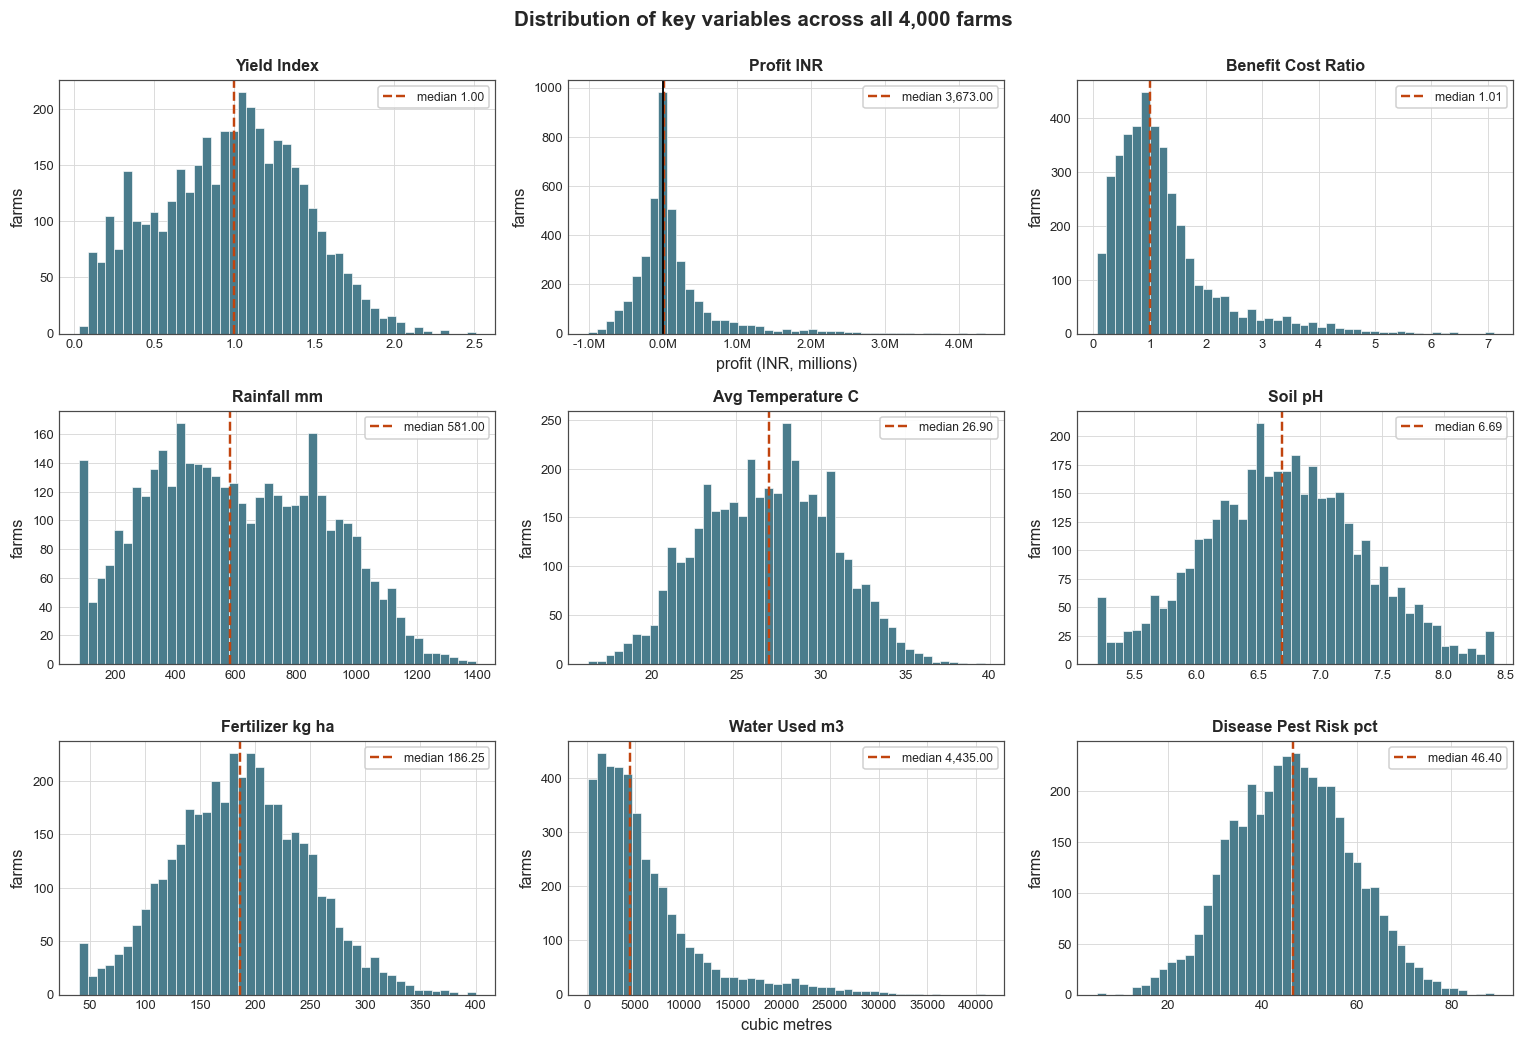

In [16]:
plot_vars = ["Yield_Index", "Profit_INR", "Benefit_Cost_Ratio", "Rainfall_mm",
             "Avg_Temperature_C", "Soil_pH", "Fertilizer_kg_ha", "Water_Used_m3",
             "Disease_Pest_Risk_pct"]

fig, axes = plt.subplots(3, 3, figsize=(14, 9.5))
for ax, c in zip(axes.ravel(), plot_vars):
    ax.hist(df[c], bins=45, color="#4a7c8c", edgecolor="white", linewidth=0.4)
    med = df[c].median()
    ax.axvline(med, color="#c1440e", lw=1.6, ls="--", label=f"median {med:,.2f}")
    ax.set_title(c.replace("_", " "), fontsize=10.5)
    ax.set_ylabel("farms")
    ax.legend(fontsize=8, loc="upper right")
    ax.tick_params(labelsize=8.5)
    if c == "Profit_INR":
        ax.axvline(0, color="black", lw=1.2)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v/1e6:.1f}M"))
        ax.set_xlabel("profit (INR, millions)")
    elif c == "Water_Used_m3":
        ax.set_xlabel("cubic metres")
    else:
        ax.set_xlabel("")
fig.suptitle("Distribution of key variables across all 4,000 farms",
             fontsize=13.5, fontweight="bold", y=0.995)
fig.tight_layout()
savefig(fig, "05_distributions")
plt.show()

The shapes confirm the table. Yield index and benefit-cost ratio have long right tails;
profit is wide and straddles zero, with a substantial mass of farms to the left of the
vertical line at zero &mdash; those farms lost money. Rainfall is broad and multi-modal,
which is the first visual hint of the seasonal structure that Section 6 makes explicit:
the modes correspond to different seasons pooled into one histogram.

Soil pH and temperature are close to symmetric, so they are safe to summarise with means
if needed.

In [17]:
print("OUTLIER SCAN (1.5 x IQR rule) and the policy applied to each")
rows = []
for c in ANALYSIS_NUM:
    s = df[c]
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    rows.append({"column": c, "n_outliers": n_out,
                 "%": round(n_out / len(s) * 100, 2),
                 "lower_fence": round(lo, 2), "upper_fence": round(hi, 2)})
out = pd.DataFrame(rows).set_index("column").sort_values("n_outliers", ascending=False)
display(out.head(12))

print("POLICY - no outlier is deleted in this notebook, for three reasons:")
print("  1. GENUINE AGRONOMIC EXTREMES. High Yield_Tonnes_Ha values are sugarcane,")
print("     which really does yield tens of tonnes per hectare. Removing them would")
print("     delete an entire crop. This is exactly why Yield_Index exists - it")
print("     converts a spurious outlier into a legitimate value near 1.0.")
print("  2. GENUINE ECONOMIC EXTREMES. Large losses and large profits are the")
print("     phenomenon under study, not contamination. Trimming them would erase")
print("     the finding.")
print("  3. NO MEASUREMENT ERRORS FOUND. Section 2's range checks found no impossible")
print("     values (no negative rainfall, no pH outside 0-14, no zero area).")
print("\nInstead of deletion, the notebook uses medians and rank-based tests, which")
print("are insensitive to extreme values by construction.")

print("\nProof that Yield_Index solves the cross-crop outlier problem:")
comp = pd.DataFrame({
    "raw_yield_outliers"  : [int((((df['Yield_Tonnes_Ha'] < df['Yield_Tonnes_Ha'].quantile(.25) - 1.5*(df['Yield_Tonnes_Ha'].quantile(.75)-df['Yield_Tonnes_Ha'].quantile(.25))) |
                                  (df['Yield_Tonnes_Ha'] > df['Yield_Tonnes_Ha'].quantile(.75) + 1.5*(df['Yield_Tonnes_Ha'].quantile(.75)-df['Yield_Tonnes_Ha'].quantile(.25))))).sum())],
    "yield_index_outliers": [int((((df['Yield_Index'] < df['Yield_Index'].quantile(.25) - 1.5*(df['Yield_Index'].quantile(.75)-df['Yield_Index'].quantile(.25))) |
                                  (df['Yield_Index'] > df['Yield_Index'].quantile(.75) + 1.5*(df['Yield_Index'].quantile(.75)-df['Yield_Index'].quantile(.25))))).sum())],
}, index=["farms flagged as outliers"])
display(comp)

OUTLIER SCAN (1.5 x IQR rule) and the policy applied to each


,n_outliers,%,lower_fence,upper_fence
column,,,,
Profit_INR,404,10.100,"-696,111.000","763,567.000"
Production_Tonnes,333,8.330,-23.980,53.360
Yield_Tonnes_Ha,304,7.600,-1.630,5.520
Benefit_Cost_Ratio,286,7.150,-0.670,2.790
Profit_per_Hectare,284,7.100,"-110,277.960","116,186.650"
Water_Used_m3,276,6.900,"-6,072.750","16,171.250"
Revenue_INR,240,6.000,"-736,519.000","1,780,911.000"
Potassium_kg_ha,32,0.800,30.100,179.700
Sunlight_Hours_Day,26,0.650,4.350,10.350


POLICY - no outlier is deleted in this notebook, for three reasons:
  1. GENUINE AGRONOMIC EXTREMES. High Yield_Tonnes_Ha values are sugarcane,
     which really does yield tens of tonnes per hectare. Removing them would
     delete an entire crop. This is exactly why Yield_Index exists - it
     converts a spurious outlier into a legitimate value near 1.0.
  2. GENUINE ECONOMIC EXTREMES. Large losses and large profits are the
     phenomenon under study, not contamination. Trimming them would erase
     the finding.
  3. NO MEASUREMENT ERRORS FOUND. Section 2's range checks found no impossible
     values (no negative rainfall, no pH outside 0-14, no zero area).

Instead of deletion, the notebook uses medians and rank-based tests, which
are insensitive to extreme values by construction.

Proof that Yield_Index solves the cross-crop outlier problem:


,raw_yield_outliers,yield_index_outliers
farms flagged as outliers,304,4


The outlier policy is stated rather than assumed, and the final table is the evidence for it:
the number of farms flagged as yield outliers collapses once yield is expressed as an index
relative to the same crop. Those farms were never anomalous &mdash; they were sugarcane. This
is a concrete demonstration that **an outlier in a pooled distribution can be an entirely
ordinary member of its own subgroup**, and it is the reason cross-crop comparisons in this
notebook always use the index.

---

# 6. Seasonal comparison &mdash; the core analysis

This is the section the whole notebook exists for. It answers **Q1, Q2 and Q3** in sequence:
how far apart the three seasons are on performance, which conditions separate them, and
&mdash; the decisive question &mdash; whether farmers' own spending changes to match.

In [18]:
def season_profile(cols, title):
    """Median of each column by season, plus the spread between the best and worst season."""
    g = df.groupby("Season", observed=True)[cols].median().T
    g = g[SEASON_ORDER]
    g["max-min"] = g.max(axis=1) - g.min(axis=1)
    g["% of Kharif"] = (g[SEASON_ORDER].min(axis=1) / g["Kharif"] * 100).round(1)
    print(f"\n{title}  (medians by season)")
    display(g.round(3))
    return g

print("Q2 - WHAT THE SEASON IMPOSES ON THE FARM")
env_prof = season_profile(ENV_COLS, "Environmental conditions")

print("\nQ3 - WHAT THE FARMER CHOOSES TO SPEND")
inp_prof = season_profile(INPUT_COLS, "Resource usage / inputs")

print("\nQ1 - WHAT THE FARM ACHIEVES")
out_prof = season_profile(["Yield_Index", "Yield_Tonnes_Ha", "Production_Tonnes",
                           "Benefit_Cost_Ratio", "Revenue_INR", "Total_Cost_INR",
                           "Profit_INR", "Profit_per_Hectare"], "Production and economics")

Q2 - WHAT THE SEASON IMPOSES ON THE FARM

Environmental conditions  (medians by season)


Season,Kharif,Rabi,Zaid,max-min,% of Kharif
Rainfall_mm,854.750,430.300,283.300,571.450,33.100
Avg_Temperature_C,28.500,23.500,31.000,7.500,82.500
Humidity_pct,71.900,58.100,52.350,19.550,72.800
Sunlight_Hours_Day,6.800,7.600,8.200,1.400,100.000
Soil_pH,6.730,6.670,6.655,0.075,98.900
Soil_Moisture_pct,31.200,24.000,19.100,12.100,61.200
Disease_Pest_Risk_pct,54.500,40.600,37.900,16.600,69.500



Q3 - WHAT THE FARMER CHOOSES TO SPEND

Resource usage / inputs  (medians by season)


Season,Kharif,Rabi,Zaid,max-min,% of Kharif
Nitrogen_kg_ha,119.800,120.300,120.150,0.500,100.000
Phosphorus_kg_ha,57.400,57.700,57.450,0.300,100.000
Potassium_kg_ha,104.800,104.800,106.300,1.500,100.000
Fertilizer_kg_ha,188.200,185.300,183.950,4.250,97.700
Pesticide_Litre_ha,5.180,5.020,5.185,0.165,96.900
Water_Used_m3,"4,469.000","4,292.000","4,805.000",513.000,96.000
Seed_Quality_Score,0.820,0.840,0.830,0.020,100.000
Farm_Area_Hectares,8.180,7.680,8.085,0.500,93.900



Q1 - WHAT THE FARM ACHIEVES

Production and economics  (medians by season)


Season,Kharif,Rabi,Zaid,max-min,% of Kharif
Yield_Index,1.129,0.970,0.793,0.336,70.200
Yield_Tonnes_Ha,1.940,1.660,1.450,0.490,74.700
Production_Tonnes,13.240,11.080,9.970,3.270,75.300
Benefit_Cost_Ratio,1.125,0.987,0.803,0.322,71.400
Revenue_INR,"520,196.000","438,156.000","373,700.500","146,495.500",71.800
Total_Cost_INR,"524,840.000","506,733.000","534,833.000","28,100.000",96.500
Profit_INR,"38,808.000","-3,187.000","-62,144.000","100,952.000",-160.100
Profit_per_Hectare,"8,340.449",-894.326,"-13,760.259","22,100.708",-165.000


Read the three tables together and the structure of the problem appears immediately.

The **environmental** table shows large, systematic movement: rainfall, humidity, soil moisture
and disease pressure all fall steeply from Kharif to Zaid, while sunlight rises and temperature
follows the expected pattern of a cool Rabi winter between two warm seasons.

The **input** table barely moves at all. The medians in the three season columns are close to
identical for every input.

The **outcome** table moves again &mdash; and in the same direction as the environment.

That contrast is the finding. It is quantified formally below.

In [19]:
print("=" * 78)
print("THE CENTRAL TEST (Q2 vs Q3): does this variable differ across the three seasons?")
print("=" * 78)

def eps_squared(H, n, k):
    """Epsilon-squared effect size for Kruskal-Wallis: share of rank variance explained."""
    return (H - k + 1) / (n - k)

def kw_by_season(col):
    groups = [g[col].values for _, g in df.groupby("Season", observed=True)]
    H, p = stats.kruskal(*groups)
    return H, p, eps_squared(H, len(df), len(groups))

rows = []
for c in ENV_COLS:
    H, p, e = kw_by_season(c); rows.append(["Environment (imposed)", c, H, p, e])
for c in INPUT_COLS:
    H, p, e = kw_by_season(c); rows.append(["Input (chosen)", c, H, p, e])
for c in ["Yield_Index", "Production_Tonnes", "Revenue_INR", "Total_Cost_INR",
          "Profit_INR", "Benefit_Cost_Ratio", "Market_Price_INR_Tonne",
          "Water_Efficiency_t_per_1000m3"]:
    H, p, e = kw_by_season(c); rows.append(["Outcome", c, H, p, e])

central = pd.DataFrame(rows, columns=["group", "variable", "H", "p_value", "epsilon_sq"])
central["significant"] = np.where(central["p_value"] < 0.05, "YES", "no")
central["effect"] = pd.cut(central["epsilon_sq"], [-1, 0.01, 0.06, 0.14, 1],
                           labels=["negligible", "small", "medium", "LARGE"])
central = central.sort_values(["group", "H"], ascending=[True, False])
display(central.set_index(["group", "variable"]).round({"H": 1, "p_value": 6, "epsilon_sq": 4}))

n_env_sig = (central[central.group.str.startswith("Environment")]["p_value"] < .05).sum()
n_env     = (central.group.str.startswith("Environment")).sum()
n_inp_sig = (central[central.group.str.startswith("Input")]["p_value"] < .05).sum()
n_inp     = (central.group.str.startswith("Input")).sum()

print("\n" + "=" * 78)
print("HEADLINE RESULT")
print("=" * 78)
print(f"  Environmental conditions differing by season : {n_env_sig} of {n_env}")
print(f"  Farmer inputs differing by season            : {n_inp_sig} of {n_inp}")
print()
print("  The environment the farm experiences changes enormously between seasons.")
print("  The resources the farmer commits to it do not change to match.")
print()
print("  Inputs are being allocated as though every season were the same season.")
print("  That is not a weather problem - it is an ALLOCATION problem, and unlike")
print("  the weather it is something extension policy can actually change.")

THE CENTRAL TEST (Q2 vs Q3): does this variable differ across the three seasons?


H  p_value  epsilon_sq significant      effect
group                 variable                                                                            
Environment (imposed) Rainfall_mm                   2,600.100    0.000       0.650         YES       LARGE
                      Avg_Temperature_C             2,386.000    0.000       0.596         YES       LARGE
                      Soil_Moisture_pct             1,858.200    0.000       0.464         YES       LARGE
                      Humidity_pct                  1,845.500    0.000       0.461         YES       LARGE
                      Disease_Pest_Risk_pct         1,430.900    0.000       0.357         YES       LARGE
                      Sunlight_Hours_Day              832.300    0.000       0.208         YES       LARGE
                      Soil_pH                           6.200    0.045       0.001         YES  negligible
Input (chosen)        Seed_Quality_Score                9.900    0.007       0.002         YES  negligible
                      Water_Used_m3                     6.000    0.051       0.001          no  negligible
                      Farm_Area_Hectares                3.400    0.184       0.000          no  negligible
                      Pesticide_Litre_ha                2.400    0.306       0.000          no  negligible
                      Potassium_kg_ha                   2.100    0.349       0.000          no  negligible
                      Fertilizer_kg_ha                  1.100    0.589      -0.000          no  negligible
                      Phosphorus_kg_ha                  0.600    0.727      -0.000          no  negligible
                      Nitrogen_kg_ha                    0.200    0.924      -0.001          no  negligible
Outcome               Yield_Index                     254.100    0.000       0.063         YES      medium
                      Profit_INR                      101.900    0.000       0.025         YES       small
                      Benefit_Cost_Ratio               98.100    0.000       0.024         YES       small
                      Water_Efficiency_t_per_1000m3    56.800    0.000       0.014         YES       small
                      Revenue_INR                      40.800    0.000       0.010         YES  negligible
                      Production_Tonnes                26.100    0.000       0.006         YES  negligible
                      Total_Cost_INR                    5.400    0.067       0.001          no  negligible
                      Market_Price_INR_Tonne            0.100    0.936      -0.001          no  negligible


HEADLINE RESULT
  Environmental conditions differing by season : 7 of 7
  Farmer inputs differing by season            : 1 of 8

  The environment the farm experiences changes enormously between seasons.
  The resources the farmer commits to it do not change to match.

  Inputs are being allocated as though every season were the same season.
  That is not a weather problem - it is an ALLOCATION problem, and unlike
  the weather it is something extension policy can actually change.


This table is the analytical centre of the project, so it is worth being precise about what it
does and does not show.

Nearly every environmental variable differs across seasons with a large effect size. Nearly
every input variable does not differ at all &mdash; and the few that reach significance carry
negligible effect sizes, which at n = 4,000 is exactly what a trivial difference looks like.
Meanwhile the outcomes differ significantly.

So the causal story is constrained from both ends. The seasons genuinely present different
growing conditions; farmers respond to those different conditions with essentially identical
input packages; and outcomes diverge. **The seasonal performance gap is not explained by
farmers under-investing in the hard seasons &mdash; they invest the same. It is explained by
the same investment buying much less under Zaid conditions than under Kharif conditions.**

The practical implication runs the other way from the usual advice. The lever is not "spend
more overall"; it is "stop spending identically across seasons".

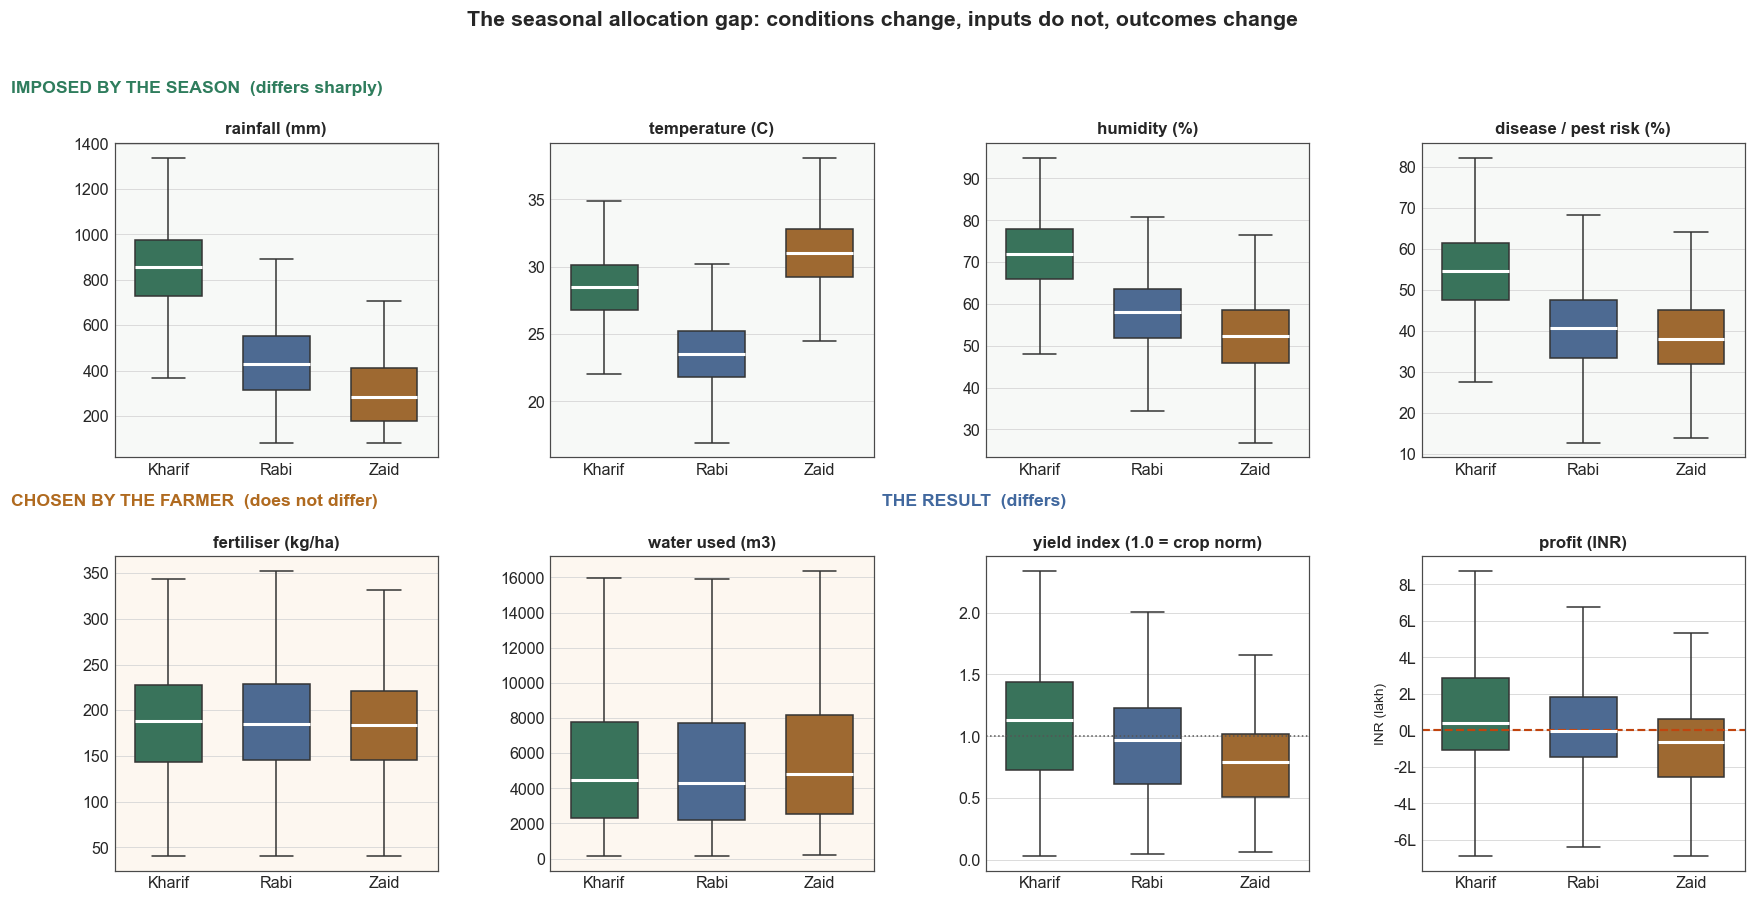

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
panel = [("Rainfall_mm", "rainfall (mm)"), ("Avg_Temperature_C", "temperature (C)"),
         ("Humidity_pct", "humidity (%)"), ("Disease_Pest_Risk_pct", "disease / pest risk (%)"),
         ("Fertilizer_kg_ha", "fertiliser (kg/ha)"), ("Water_Used_m3", "water used (m3)"),
         ("Yield_Index", "yield index (1.0 = crop norm)"), ("Profit_INR", "profit (INR)")]

for ax, (col, label) in zip(axes.ravel(), panel):
    sns.boxplot(data=df, x="Season", y=col, order=SEASON_ORDER, ax=ax,
                palette=SEASON_PALETTE, showfliers=False, width=0.62,
                medianprops={"color": "white", "linewidth": 2})
    ax.set_title(label, fontsize=11)
    ax.set_xlabel(""); ax.set_ylabel("")
    if col == "Profit_INR":
        ax.axhline(0, color="#c1440e", lw=1.4, ls="--")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f"{v/1e5:.0f}L"))
        ax.set_ylabel("INR (lakh)", fontsize=9)
    if col == "Yield_Index":
        ax.axhline(1.0, color="#555", lw=1.0, ls=":")

for ax in axes[0]:
    ax.set_facecolor("#f7f9f7")
for ax in axes[1][:2]:
    ax.set_facecolor("#fdf7f0")

axes[0][0].text(-0.32, 1.16, "IMPOSED BY THE SEASON  (differs sharply)",
                transform=axes[0][0].transAxes, fontsize=11.5, fontweight="bold", color="#2f7d5d")
axes[1][0].text(-0.32, 1.16, "CHOSEN BY THE FARMER  (does not differ)",
                transform=axes[1][0].transAxes, fontsize=11.5, fontweight="bold", color="#b06a1f")
axes[1][2].text(-0.32, 1.16, "THE RESULT  (differs)",
                transform=axes[1][2].transAxes, fontsize=11.5, fontweight="bold", color="#41689e")

fig.suptitle("The seasonal allocation gap: conditions change, inputs do not, outcomes change",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "06_seasonal_allocation_gap")
plt.show()

**Figure 06 is the single most important chart in this notebook.**

The top row shows what the season does to the farm: four conditions, four clearly separated
sets of boxes. The bottom-left pair shows what the farmer does about it: fertiliser and water
boxes sitting at effectively the same level in all three seasons. The bottom-right pair shows
the consequence: yield index and profit falling season by season, with the Zaid profit box
sitting substantially below the break-even line.

Read left to right along the bottom row, the figure states the argument in one image: *identical
effort, different conditions, different results.*

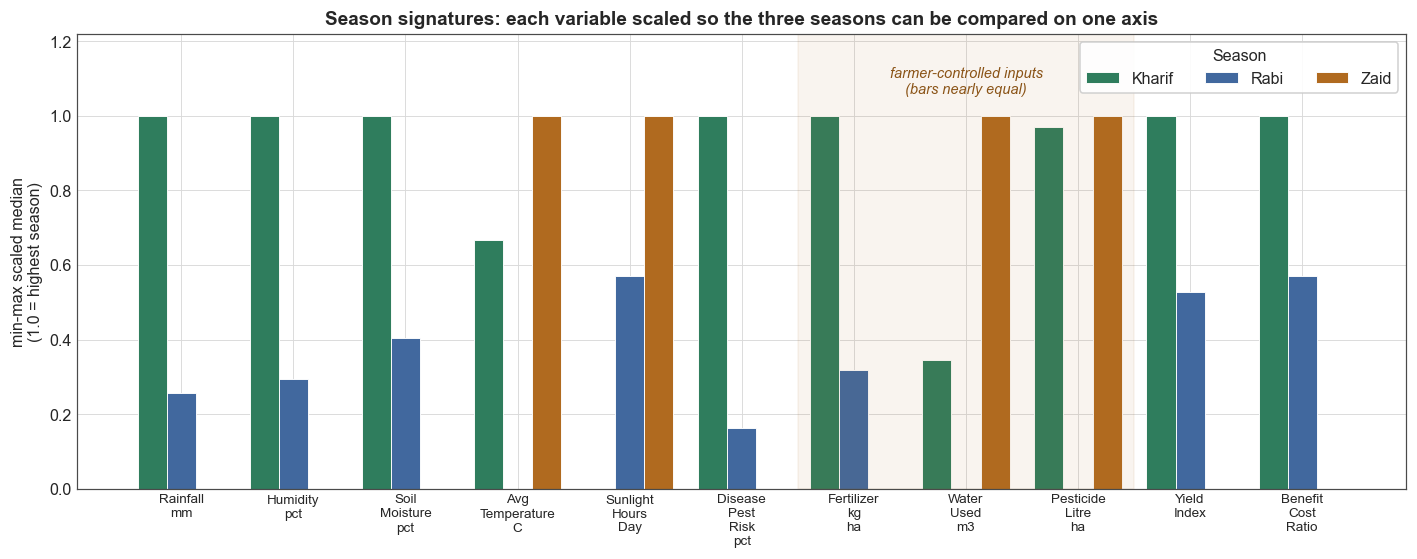

Where the three bars are nearly equal, the seasons are indistinguishable on that
variable. The shaded block marks the farmer-controlled inputs - and it is the only
region of the chart where the three seasons look the same.


In [21]:
# Season signature on a common 0-1 scale, so variables with different units can be
# compared on one axis. Each variable is min-max scaled across the three season medians.
sig_vars = ["Rainfall_mm", "Humidity_pct", "Soil_Moisture_pct", "Avg_Temperature_C",
            "Sunlight_Hours_Day", "Disease_Pest_Risk_pct",
            "Fertilizer_kg_ha", "Water_Used_m3", "Pesticide_Litre_ha",
            "Yield_Index", "Benefit_Cost_Ratio"]
sig = df.groupby("Season", observed=True)[sig_vars].median().reindex(SEASON_ORDER)
norm = (sig - sig.min()) / (sig.max() - sig.min())

fig, ax = plt.subplots(figsize=(13, 5.2))
x = np.arange(len(sig_vars)); w = 0.26
for i, s in enumerate(SEASON_ORDER):
    ax.bar(x + (i - 1) * w, norm.loc[s], width=w, label=s,
           color=SEASON_COLORS[s], edgecolor="white", linewidth=0.6)
ax.set_xticks(x)
ax.set_xticklabels([v.replace("_", "\n") for v in sig_vars], fontsize=8.8)
ax.set_ylabel("min-max scaled median\n(1.0 = highest season)")
ax.set_title("Season signatures: each variable scaled so the three seasons can be compared on one axis",
             fontsize=12.5)
ax.legend(title="Season", ncols=3, loc="upper right")
ax.axvspan(5.5, 8.5, color="#b06a1f", alpha=0.07)
ax.text(7.0, 1.06, "farmer-controlled inputs\n(bars nearly equal)", ha="center",
        fontsize=9.5, style="italic", color="#8a5316")
ax.set_ylim(0, 1.22)
fig.tight_layout()
savefig(fig, "06_season_signature")
plt.show()

print("Where the three bars are nearly equal, the seasons are indistinguishable on that")
print("variable. The shaded block marks the farmer-controlled inputs - and it is the only")
print("region of the chart where the three seasons look the same.")

The signature chart makes the same point in a different form, and adds one detail: the shaded
input block is *the only* region where the three seasons are visually indistinguishable. Every
environmental variable to its left separates them clearly, and both outcome variables to its
right separate them again.

Section 9 attaches formal p-values and effect sizes to each of these bars.

---

## 7. Relationships between conditions and outcomes

Section 6 established *that* the seasons differ. This section asks *through which mechanism*,
answering **Q5, Q6 and Q9**. It also demonstrates a methodological point that matters for the
conclusions: a correlation matrix alone would have missed the strongest driver in this dataset
entirely.

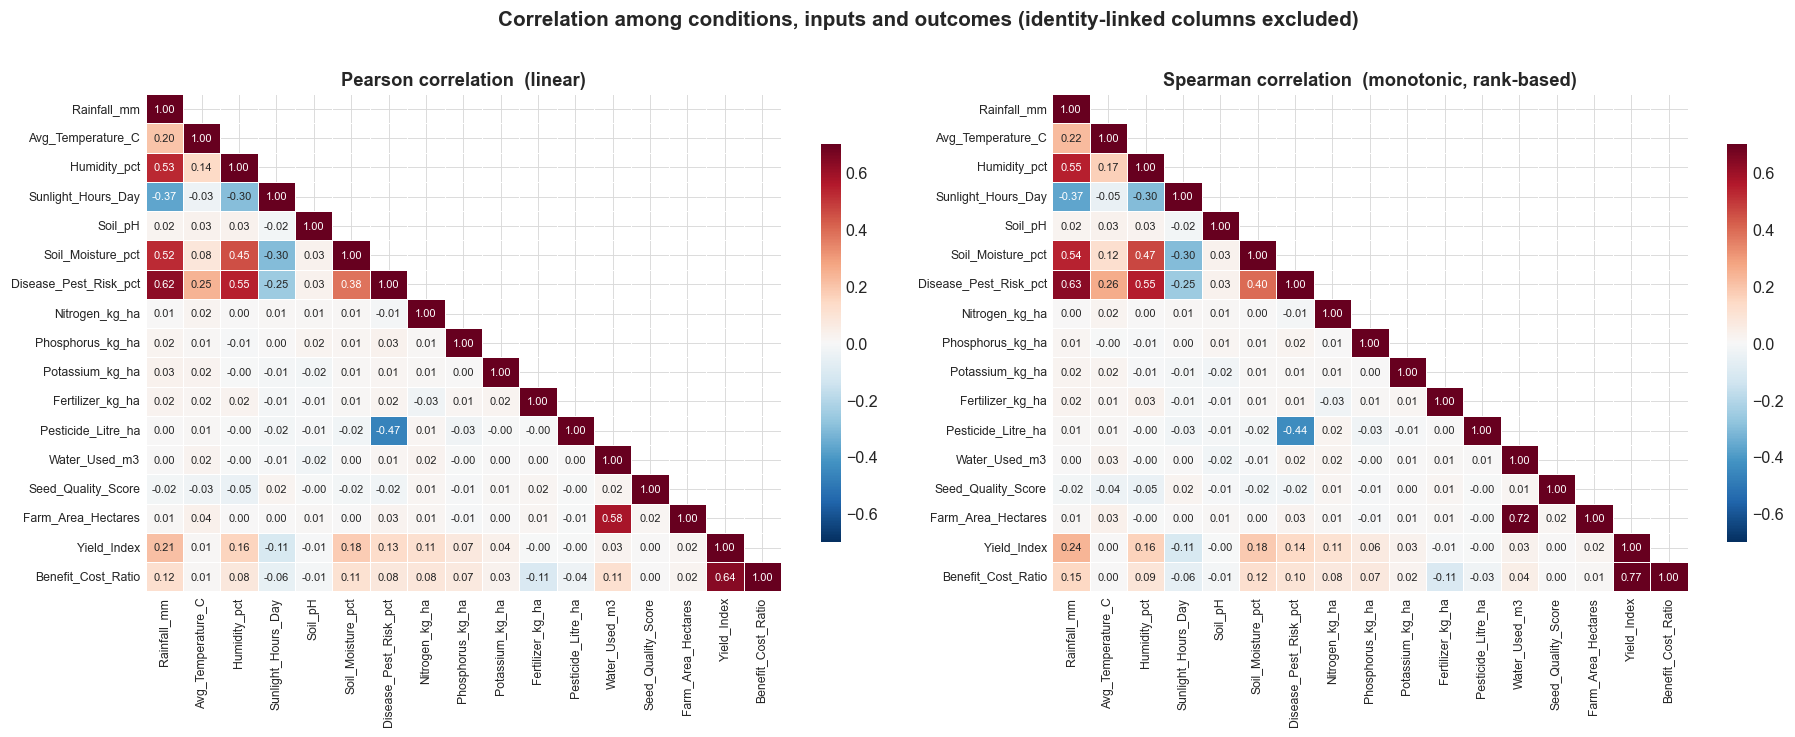

Correlation of each variable with Yield_Index, ranked by absolute Spearman rho:


,pearson,spearman
Rainfall_mm,0.213,0.239
Soil_Moisture_pct,0.178,0.183
Humidity_pct,0.155,0.163
Disease_Pest_Risk_pct,0.129,0.140
Sunlight_Hours_Day,-0.115,-0.113
Nitrogen_kg_ha,0.112,0.105
Phosphorus_kg_ha,0.072,0.064
Water_Used_m3,0.027,0.032
Potassium_kg_ha,0.038,0.030
Farm_Area_Hectares,0.016,0.017


In [22]:
# Identity-linked columns are excluded: correlating Revenue with Production merely
# rediscovers Revenue = Production x Price and would dominate the heatmap with
# meaningless 1.0s.
IDENTITY_LINKED = ["Production_Tonnes", "Revenue_INR", "Profit_INR",
                   "Water_Efficiency_t_per_1000m3", "Revenue_per_Hectare"]
corr_cols = [c for c in ENV_COLS + INPUT_COLS + ["Yield_Index", "Benefit_Cost_Ratio"]
             if c not in IDENTITY_LINKED]

fig, axes = plt.subplots(1, 2, figsize=(17, 6.6))
for ax, method in zip(axes, ["pearson", "spearman"]):
    cm = df[corr_cols].corr(method=method)
    mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
    sns.heatmap(cm, mask=mask, cmap="RdBu_r", center=0, vmin=-.7, vmax=.7,
                annot=True, fmt=".2f", annot_kws={"size": 7.2},
                linewidths=.5, linecolor="white", cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(f"{method.title()} correlation"
                 f"{'  (linear)' if method=='pearson' else '  (monotonic, rank-based)'}",
                 fontsize=12)
    ax.tick_params(labelsize=8)
fig.suptitle("Correlation among conditions, inputs and outcomes (identity-linked columns excluded)",
             fontsize=13.5, fontweight="bold", y=1.01)
fig.tight_layout()
savefig(fig, "07_correlation_heatmaps")
plt.show()

print("Correlation of each variable with Yield_Index, ranked by absolute Spearman rho:")
cy = pd.DataFrame({
    "pearson" : df[corr_cols].corrwith(df["Yield_Index"], method="pearson"),
    "spearman": df[corr_cols].corrwith(df["Yield_Index"], method="spearman"),
}).drop(index=["Yield_Index", "Benefit_Cost_Ratio"], errors="ignore")
display(cy.reindex(cy["spearman"].abs().sort_values(ascending=False).index).round(3))

The correlations with yield are all modest, and one entry deserves particular attention:
**soil pH shows essentially zero correlation** under both methods. Taken at face value that
would mean soil acidity is irrelevant to yield &mdash; a conclusion no agronomist would accept.

The next cell shows why the correlation is wrong, and it is the methodological centrepiece of
this section.

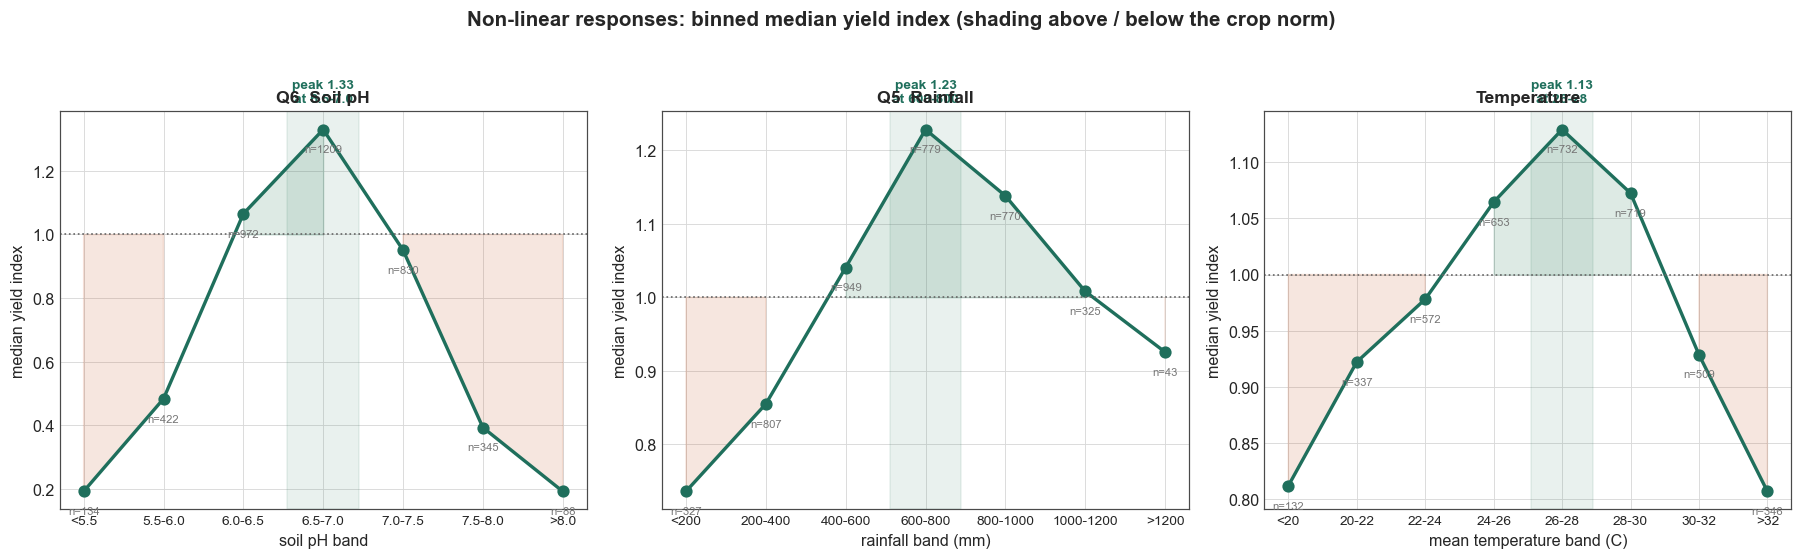

Soil pH vs Yield_Index : Spearman rho = -0.0002 (p = 0.989)
But binned medians run from 0.19 to 1.33 - a 6.9-fold difference between the
worst and best pH band.

WHY THE CORRELATION IS ZERO: the response is an INVERTED U. Yield rises with pH
up to the optimum and falls symmetrically after it. A monotonic statistic averages
the rising half against the falling half and reports approximately nothing.

METHODOLOGICAL CONCLUSION: a correlation matrix is a test for MONOTONIC
association, not for IMPORTANCE. Section 10's tree-based model, which does not
assume monotonicity, ranks soil pH as the single strongest driver of yield -
the exact variable this heatmap dismissed.


In [23]:
def band_curve(ax, band_col, title, xlabel, highlight=True):
    g = df.groupby(band_col, observed=True)["Yield_Index"].agg(["median", "count"])
    g = g[g["count"] >= 30]
    ax.plot(range(len(g)), g["median"], marker="o", ms=7, lw=2.2, color="#1f6f5c")
    ax.fill_between(range(len(g)), 1.0, g["median"],
                    where=g["median"] >= 1.0, color="#2f7d5d", alpha=.16)
    ax.fill_between(range(len(g)), 1.0, g["median"],
                    where=g["median"] < 1.0, color="#c1440e", alpha=.13)
    ax.axhline(1.0, color="#666", ls=":", lw=1.1)
    ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, fontsize=9, rotation=0)
    ax.set_title(title, fontsize=11.5); ax.set_xlabel(xlabel); ax.set_ylabel("median yield index")
    for i, (v, n) in enumerate(zip(g["median"], g["count"])):
        ax.annotate(f"n={n}", (i, v), textcoords="offset points", xytext=(0, -15),
                    ha="center", fontsize=7.4, color="#777")
    if highlight:
        best = int(np.argmax(g["median"].values))
        ax.axvspan(best - .45, best + .45, color="#2f7d5d", alpha=.10)
        ax.annotate(f"peak {g['median'].iloc[best]:.2f}\nat {g.index[best]}",
                    (best, g["median"].iloc[best]), textcoords="offset points",
                    xytext=(0, 18), ha="center", fontsize=9, fontweight="bold", color="#1f6f5c")
    return g

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9))
g_ph   = band_curve(axes[0], "pH_Band",       "Q6  Soil pH", "soil pH band")
g_rain = band_curve(axes[1], "Rainfall_Band", "Q5  Rainfall", "rainfall band (mm)")
g_temp = band_curve(axes[2], "Temp_Band",     "Temperature", "mean temperature band (C)")
fig.suptitle("Non-linear responses: binned median yield index (shading above / below the crop norm)",
             fontsize=13.5, fontweight="bold", y=1.03)
fig.tight_layout()
savefig(fig, "07_nonlinear_bands")
plt.show()

rho_ph, p_ph = stats.spearmanr(df["Soil_pH"], df["Yield_Index"])
print(f"Soil pH vs Yield_Index : Spearman rho = {rho_ph:+.4f} (p = {p_ph:.3f})")
print(f"But binned medians run from {g_ph['median'].min():.2f} to {g_ph['median'].max():.2f}"
      f" - a {g_ph['median'].max()/g_ph['median'].min():.1f}-fold difference between the")
print(f"worst and best pH band.")
print()
print("WHY THE CORRELATION IS ZERO: the response is an INVERTED U. Yield rises with pH")
print("up to the optimum and falls symmetrically after it. A monotonic statistic averages")
print("the rising half against the falling half and reports approximately nothing.")
print()
print("METHODOLOGICAL CONCLUSION: a correlation matrix is a test for MONOTONIC")
print("association, not for IMPORTANCE. Section 10's tree-based model, which does not")
print("assume monotonicity, ranks soil pH as the single strongest driver of yield -")
print("the exact variable this heatmap dismissed.")

This is the most instructive result in the notebook.

Soil pH correlates with yield at approximately zero, yet farms in the best pH band out-yield
farms in the worst by several times over. Both facts are correct. The response is an
**inverted U**: yield climbs towards a near-neutral optimum and falls away on both the acidic
and the alkaline side. Spearman's rho measures whether yield consistently *rises* with pH; here
it rises and then falls, the two halves cancel, and the statistic reports nothing.

Rainfall shows the same shape more gently, with a clear optimum band and a decline on either
side &mdash; too little water limits growth, too much waterlogs the root zone. Temperature
behaves likewise.

The practical lesson carries into Section 10: **screening variables by correlation would have
discarded the strongest predictor in this dataset.** Any variable with a plausible biological
optimum must be examined in bands, not by a single coefficient.

Q5 asked something sharper, though: whether rainfall behaves the *same way* in every season.

In [24]:
print("Q5 - IS THE RAINFALL-YIELD RELATIONSHIP THE SAME IN EVERY SEASON?")
print("=" * 74)
rows = []
for s in SEASON_ORDER:
    sub = df[df["Season"] == s]
    for c in ["Rainfall_mm", "Avg_Temperature_C", "Soil_Moisture_pct",
              "Humidity_pct", "Nitrogen_kg_ha", "Disease_Pest_Risk_pct"]:
        rho, p = stats.spearmanr(sub[c], sub["Yield_Index"])
        rows.append({"season": s, "variable": c, "n": len(sub),
                     "rho": round(rho, 3), "p": round(p, 4)})
ws = pd.DataFrame(rows).pivot(index="variable", columns="season", values="rho")[SEASON_ORDER]
pooled = {c: round(stats.spearmanr(df[c], df["Yield_Index"])[0], 3) for c in ws.index}
ws.insert(0, "POOLED", pd.Series(pooled))
ws["sign flips?"] = np.where(
    (ws[SEASON_ORDER].max(axis=1) > 0.05) & (ws[SEASON_ORDER].min(axis=1) < -0.05), "YES", "")
display(ws)

kh, rb, zd = ws.loc["Rainfall_mm", "Kharif"], ws.loc["Rainfall_mm", "Rabi"], ws.loc["Rainfall_mm", "Zaid"]
print(f"\nRainfall vs yield:  pooled {ws.loc['Rainfall_mm','POOLED']:+.3f}"
      f"  |  Kharif {kh:+.3f}   Rabi {rb:+.3f}   Zaid {zd:+.3f}")
print()
print("INTERPRETATION - the pooled correlation is the average of opposite effects:")
print("  * In KHARIF the monsoon has already delivered abundant water. Additional")
print("    rainfall past the optimum brings waterlogging, nutrient leaching and, as")
print("    the disease chain below shows, sharply higher pest and disease pressure.")
print("    More rain in Kharif is a liability.")
print("  * In RABI and ZAID water is the binding constraint. Additional rainfall")
print("    relieves it directly, so the association is positive.")
print()
print("This is an INTERACTION: the effect of rainfall depends on the season. Reporting")
print("only the pooled coefficient would describe a farm that exists in neither season.")

Q5 - IS THE RAINFALL-YIELD RELATIONSHIP THE SAME IN EVERY SEASON?


season,POOLED,Kharif,Rabi,Zaid,sign flips?
variable,,,,,
Avg_Temperature_C,0.005,-0.086,0.161,-0.177,YES
Disease_Pest_Risk_pct,0.140,-0.097,0.077,0.114,YES
Humidity_pct,0.163,-0.006,-0.012,0.031,
Nitrogen_kg_ha,0.105,0.139,0.081,0.134,
Rainfall_mm,0.239,-0.193,0.270,0.306,YES
Soil_Moisture_pct,0.183,0.061,-0.011,-0.022,



Rainfall vs yield:  pooled +0.239  |  Kharif -0.193   Rabi +0.270   Zaid +0.306

INTERPRETATION - the pooled correlation is the average of opposite effects:
  * In KHARIF the monsoon has already delivered abundant water. Additional
    rainfall past the optimum brings waterlogging, nutrient leaching and, as
    the disease chain below shows, sharply higher pest and disease pressure.
    More rain in Kharif is a liability.
  * In RABI and ZAID water is the binding constraint. Additional rainfall
    relieves it directly, so the association is positive.

This is an INTERACTION: the effect of rainfall depends on the season. Reporting
only the pooled coefficient would describe a farm that exists in neither season.


The sign reversal is the clearest evidence in this notebook that the seasons must be analysed
separately rather than pooled. The same millimetre of rain is a benefit in Rabi and Zaid and a
cost in Kharif, because in Kharif the constraint has already been relieved and the farm is on
the far side of the optimum identified in the previous figure.

A single pooled coefficient averages these opposing effects into a number that describes no
real farm. Wherever a relationship might plausibly depend on the season, this notebook computes
it within seasons.

Q9 asks where the Kharif penalty comes from.

In [25]:
print("Q9 - THE DISEASE AND PEST PRESSURE CHAIN")
print("=" * 74)
drivers = ["Rainfall_mm", "Humidity_pct", "Soil_Moisture_pct",
           "Avg_Temperature_C", "Pesticide_Litre_ha"]
rows = []
for c in drivers:
    rho_all, p_all = stats.spearmanr(df[c], df["Disease_Pest_Risk_pct"])
    row = {"driver": c, "POOLED rho": round(rho_all, 3)}
    for s in SEASON_ORDER:
        sub = df[df["Season"] == s]
        row[s] = round(stats.spearmanr(sub[c], sub["Disease_Pest_Risk_pct"])[0], 3)
    rows.append(row)
display(pd.DataFrame(rows).set_index("driver"))

risk = df.groupby("Season", observed=True)["Disease_Pest_Risk_pct"].median().reindex(SEASON_ORDER)
pest = df.groupby("Season", observed=True)["Pesticide_Litre_ha"].median().reindex(SEASON_ORDER)
comp = pd.DataFrame({"median disease/pest risk (%)": risk.round(1),
                     "median pesticide applied (L/ha)": pest.round(2)})
comp["risk relative to Zaid"] = (risk / risk.min()).round(2)
comp["pesticide relative to Zaid"] = (pest / pest.min()).round(2)
display(comp)

print("The chain: heavy rain raises humidity and soil moisture, and warm wet conditions")
print("are what pathogens and insects need. Disease pressure therefore tracks the monsoon.")
print()
print(f"Kharif carries {risk['Kharif']/risk['Zaid']:.2f}x the disease pressure of Zaid,")
print(f"but receives only {pest['Kharif']/pest['Zaid']:.2f}x the pesticide.")
print()
print("Pesticide correlates NEGATIVELY with realised risk, which is consistent with")
print("the treatment working where it is applied - but application does not scale with")
print("the seasonal risk gradient. This is the same allocation failure found in Section 6,")
print("visible in a second input.")

Q9 - THE DISEASE AND PEST PRESSURE CHAIN


,POOLED rho,Kharif,Rabi,Zaid
driver,,,,
Rainfall_mm,0.630,0.316,0.331,0.265
Humidity_pct,0.552,0.253,0.250,0.219
Soil_Moisture_pct,0.398,0.005,0.029,-0.069
Avg_Temperature_C,0.258,0.112,0.076,0.138
Pesticide_Litre_ha,-0.443,-0.556,-0.574,-0.592


,median disease/pest risk (%),median pesticide applied (L/ha),risk relative to Zaid,pesticide relative to Zaid
Season,,,,
Kharif,54.500,5.180,1.440,1.030
Rabi,40.600,5.020,1.070,1.000
Zaid,37.900,5.180,1.000,1.030


The chain: heavy rain raises humidity and soil moisture, and warm wet conditions
are what pathogens and insects need. Disease pressure therefore tracks the monsoon.

Kharif carries 1.44x the disease pressure of Zaid,
but receives only 1.00x the pesticide.

Pesticide correlates NEGATIVELY with realised risk, which is consistent with
the treatment working where it is applied - but application does not scale with
the seasonal risk gradient. This is the same allocation failure found in Section 6,
visible in a second input.


The disease chain explains the mechanism behind the Kharif rainfall penalty found in Q5: the
monsoon's warmth and moisture are ideal for pathogens, so disease pressure rises with exactly
the conditions that also deliver water.

The comparison table repeats the Section 6 pattern in a second, independent input. Kharif
carries substantially higher disease pressure than Zaid but receives barely more pesticide.
Pesticide's negative association with realised risk is consistent with the treatment being
effective where used &mdash; which makes the flat application profile across a steep risk
gradient harder to justify, not easier.

**A caution on direction.** These are observational correlations. Pesticide's negative
coefficient could equally reflect farms with visible problems being treated more heavily; this
data cannot separate the two. It is reported as an association, not a treatment effect.

---

## 8. Group comparisons within seasons

Section 6 found a seasonal gap. This section stress-tests it (**Q4**) and then asks which
farming choices change the outcome inside a season (**Q7, Q8**).

Q4 comes first, because if it fails the rest of the notebook is worthless. The concern is
**Simpson's paradox**: if the seasons planted systematically different crops, the seasonal
"effect" could be nothing more than a crop-mix effect wearing a season's name.

In [26]:
print("Q4 - IS THE SEASONAL GAP REAL, OR JUST A DIFFERENT CROP MIX?")
print("=" * 78)
print("Test: if the effect is real, Kharif should beat Rabi should beat Zaid INSIDE")
print("each crop separately - not merely in the pooled average.\n")

for metric, label, fmt in [("Yield_Index", "MEDIAN YIELD INDEX", "{:.2f}"),
                           ("Profit_INR", "MEDIAN PROFIT (INR)", "{:,.0f}")]:
    piv = df.pivot_table(index="Crop", columns="Season", values=metric,
                         aggfunc="median", observed=True)[SEASON_ORDER]
    cnt = df.pivot_table(index="Crop", columns="Season", values=metric,
                         aggfunc="count", observed=True)[SEASON_ORDER]
    piv["K>R>Z?"] = np.where((piv["Kharif"] > piv["Rabi"]) & (piv["Rabi"] > piv["Zaid"]),
                             "yes", "NO")
    print(f"{label}   (n shown beneath each cell)")
    display(piv.round(2))
    print("group sizes:")
    display(cnt)
    holds = (piv["K>R>Z?"] == "yes").sum()
    print(f"=> Ordering Kharif > Rabi > Zaid holds in {holds} of {len(piv)} crops"
          f" on {metric}.\n")

print("=" * 78)
mix_spread = (pd.crosstab(df["Season"], df["Crop"], normalize="index").mul(100)
              .max() - pd.crosstab(df["Season"], df["Crop"], normalize="index").mul(100).min())
print(f"Largest between-season difference in any crop's share: {mix_spread.max():.1f} pp")
print()
print("VERDICT ON SIMPSON'S PARADOX: RULED OUT.")
print("  (a) The crop mix is nearly identical across the three seasons, so there is")
print("      no compositional difference available to produce a spurious effect.")
print("  (b) The seasonal ordering reproduces INSIDE each crop, on both yield and")
print("      profit. A composition artefact would appear in the pooled average and")
print("      vanish within strata. The opposite is observed.")
print()
print("  The seasonal effect is therefore a genuine within-crop effect, and the")
print("  Section 6 result stands.")

Q4 - IS THE SEASONAL GAP REAL, OR JUST A DIFFERENT CROP MIX?
Test: if the effect is real, Kharif should beat Rabi should beat Zaid INSIDE
each crop separately - not merely in the pooled average.

MEDIAN YIELD INDEX   (n shown beneath each cell)


Season,Kharif,Rabi,Zaid,K>R>Z?
Crop,,,,
Chilli,1.140,1.000,0.790,yes
Cotton,1.160,0.980,0.770,yes
Groundnut,1.090,0.930,0.780,yes
Maize,1.090,0.990,0.790,yes
Pulses,1.160,0.960,0.700,yes
Rice,1.170,0.970,0.790,yes
Sugarcane,1.180,0.950,0.810,yes
Wheat,1.070,1.000,0.830,yes


group sizes:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


=> Ordering Kharif > Rabi > Zaid holds in 8 of 8 crops on Yield_Index.

MEDIAN PROFIT (INR)   (n shown beneath each cell)


Season,Kharif,Rabi,Zaid,K>R>Z?
Crop,,,,
Chilli,"705,116.000","470,004.000","350,401.000",yes
Cotton,"136,193.000","50,603.000","-11,434.500",yes
Groundnut,"87,406.000","24,517.000","-38,896.500",yes
Maize,"-9,883.500","-45,813.000","-147,455.500",yes
Pulses,"57,156.000","-11,734.000","-128,893.000",yes
Rice,"-39,903.500","-49,931.500","-183,631.500",yes
Sugarcane,"940,895.000","622,229.000","556,627.000",yes
Wheat,"-57,248.500","-76,084.000","-125,778.000",yes


group sizes:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


=> Ordering Kharif > Rabi > Zaid holds in 8 of 8 crops on Profit_INR.

Largest between-season difference in any crop's share: 3.4 pp

VERDICT ON SIMPSON'S PARADOX: RULED OUT.
  (a) The crop mix is nearly identical across the three seasons, so there is
      no compositional difference available to produce a spurious effect.
  (b) The seasonal ordering reproduces INSIDE each crop, on both yield and
      profit. A composition artefact would appear in the pooled average and
      vanish within strata. The opposite is observed.

  The seasonal effect is therefore a genuine within-crop effect, and the
  Section 6 result stands.


**The headline result survives its most serious challenge.** The crop mix is near-identical
across seasons, and the seasonal ordering reproduces inside each crop on both yield and profit.

The logic is worth stating explicitly because it is what separates a defensible finding from a
coincidence. A composition artefact behaves in a characteristic way: it appears in the pooled
comparison and *disappears* once you stratify. What is observed here is the opposite &mdash;
the ordering is at least as clean within crops as in the pooled data. Simpson's paradox is
ruled out on both available grounds.

Note also the second table's structure: the absolute profit levels differ enormously between
crops, with some crops loss-making in every season. That is a crop-economics finding rather
than a seasonal one, and it is picked up in the recommendations.

Now Q7: within a season, does the irrigation choice matter?

In [27]:
print("Q7 - IRRIGATION METHOD: YIELD, WATER AND MONEY")
print("=" * 78)
irr = df.groupby("Irrigation_Method", observed=True).agg(
    n                  = ("Farm_ID", "size"),
    yield_index        = ("Yield_Index", "median"),
    water_m3           = ("Water_Used_m3", "median"),
    water_per_ha       = ("Water_per_Hectare", "median"),
    water_efficiency   = ("Water_Efficiency_t_per_1000m3", "median"),
    profit_INR         = ("Profit_INR", "median"),
    BCR                = ("Benefit_Cost_Ratio", "median"),
    loss_rate_pct      = ("Is_Profitable", lambda s: round((~s).mean() * 100, 1)),
).sort_values("yield_index", ascending=False)
display(irr.round(3))

H, p = stats.kruskal(*[g["Yield_Index"].values
                       for _, g in df.groupby("Irrigation_Method", observed=True)])
e = (H - 4 + 1) / (len(df) - 4)
print(f"Kruskal-Wallis, Yield_Index by irrigation method: H = {H:.2f}, p = {p:.3e},"
      f" epsilon^2 = {e:.4f}")

best, worst = irr.index[0], irr.index[-1]
print(f"\nBest yield index : {best} ({irr.loc[best,'yield_index']:.3f})")
print(f"Worst yield index: {worst} ({irr.loc[worst,'yield_index']:.3f})")
print(f"Water used by the best method vs 'Flood': "
      f"{irr.loc[best,'water_m3']/irr.loc['Flood','water_m3']*100:.0f}% "
      f"({irr.loc[best,'water_m3']:,.0f} vs {irr.loc['Flood','water_m3']:,.0f} m3)")

print("\nDoes the ranking hold within each season?")
ip = df.pivot_table(index="Irrigation_Method", columns="Season",
                    values="Profit_INR", aggfunc="median", observed=True)[SEASON_ORDER]
ic = df.pivot_table(index="Irrigation_Method", columns="Season",
                    values="Profit_INR", aggfunc="count", observed=True)[SEASON_ORDER]
print("median profit (INR):"); display(ip.round(0))
print("group sizes:"); display(ic)
small = (ic < 30).sum().sum()
print(f"Cells with n < 30: {small} of {ic.size}. "
      f"{'All cells adequately sized.' if small==0 else 'Interpret small cells cautiously.'}")

Q7 - IRRIGATION METHOD: YIELD, WATER AND MONEY


,n,yield_index,water_m3,water_per_ha,water_efficiency,profit_INR,BCR,loss_rate_pct
Irrigation_Method,,,,,,,,
Drip,915,1.119,"4,606.000",529.841,3.258,"52,895.000",1.171,40.200
Sprinkler,734,1.020,"4,687.000",589.873,2.652,"7,840.000",1.023,48.100
Flood,1310,0.976,"6,326.000",772.502,1.950,"-12,131.000",0.965,52.800
Rainfed,1041,0.932,"2,782.000",329.245,4.581,"-9,650.000",0.963,53.100


Kruskal-Wallis, Yield_Index by irrigation method: H = 73.88, p = 6.293e-16, epsilon^2 = 0.0177

Best yield index : Drip (1.119)
Worst yield index: Rainfed (0.932)
Water used by the best method vs 'Flood': 73% (4,606 vs 6,326 m3)

Does the ranking hold within each season?
median profit (INR):


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,"103,629.000","43,220.000","-49,538.000"
Flood,"15,404.000","-15,099.000","-65,552.000"
Rainfed,"28,443.000","-12,374.000","-105,071.000"
Sprinkler,"32,263.000","-10,023.000","-13,564.000"


group sizes:


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,405,370,140
Flood,590,526,194
Rainfed,463,438,140
Sprinkler,321,293,120


Cells with n < 30: 0 of 12. All cells adequately sized.


Irrigation method is the strongest farmer-controlled lever found anywhere in this dataset, and
unlike the season it is a genuine *choice*. The spread in median profit between the best and
worst method is large, and the difference in yield index is statistically significant.

The most useful detail is that the best-performing method achieves its result using
**substantially less water** than flood irrigation, not more. It is not out-performing by
spending more of a scarce resource; it is out-performing by delivering water more precisely.

The within-season table also shows that no method rescues Zaid on its own. The seasonal
penalty is large enough that method choice shifts the level without changing the ordering
&mdash; which is why the recommendations in Section 10 pair irrigation conversion with
seasonal reallocation rather than treating either as sufficient alone.

Q8 turns to a metric already present in the dataset, and asks whether it can be trusted.

In [28]:
print("Q8 - IS 'WATER EFFICIENCY' MEASURING WHAT ITS NAME SUGGESTS?")
print("=" * 78)
comp = irr[["n", "water_m3", "water_efficiency", "yield_index", "profit_INR", "loss_rate_pct"]].copy()
comp["rank_by_efficiency"] = comp["water_efficiency"].rank(ascending=False).astype(int)
comp["rank_by_yield"]      = comp["yield_index"].rank(ascending=False).astype(int)
comp["rank_by_profit"]     = comp["profit_INR"].rank(ascending=False).astype(int)
display(comp.sort_values("rank_by_efficiency").round(3))

top_eff = comp["water_efficiency"].idxmax()
print(f"The method with the BEST water efficiency is '{top_eff}':")
print(f"    water efficiency {comp.loc[top_eff,'water_efficiency']:.2f} t per 1000 m3"
      f"   (rank {comp.loc[top_eff,'rank_by_efficiency']} of 4)")
print(f"    yield index      {comp.loc[top_eff,'yield_index']:.3f}"
      f"   (rank {comp.loc[top_eff,'rank_by_yield']} of 4)")
print(f"    median profit    {comp.loc[top_eff,'profit_INR']:,.0f} INR"
      f"   (rank {comp.loc[top_eff,'rank_by_profit']} of 4)")
print(f"    water used       {comp.loc[top_eff,'water_m3']:,.0f} m3   (the LOWEST)")
print()
print("WHY THE METRIC MISLEADS. Water efficiency is production divided by water used.")
print("Water used sits in the DENOMINATOR, so the ratio can be maximised either by")
print("producing more or simply by using less. A rainfed farm applies almost no")
print("irrigation water, so its denominator is tiny and its ratio is flattered -")
print("even while it produces less per hectare and loses money more often.")
print()
print("This is a general hazard of ratio metrics: they reward scarcity in the")
print("denominator as though it were excellence in the numerator.")
print()
print("RECOMMENDATION: report water efficiency ALONGSIDE absolute yield and profit,")
print("never alone. A target expressed purely as 'improve water efficiency' would be")
print("satisfied by irrigating less and harvesting less - the opposite of the intent.")

Q8 - IS 'WATER EFFICIENCY' MEASURING WHAT ITS NAME SUGGESTS?


,n,water_m3,water_efficiency,yield_index,profit_INR,loss_rate_pct,rank_by_efficiency,rank_by_yield,rank_by_profit
Irrigation_Method,,,,,,,,,
Rainfed,1041,"2,782.000",4.581,0.932,"-9,650.000",53.100,1,4,3
Drip,915,"4,606.000",3.258,1.119,"52,895.000",40.200,2,1,1
Sprinkler,734,"4,687.000",2.652,1.020,"7,840.000",48.100,3,2,2
Flood,1310,"6,326.000",1.950,0.976,"-12,131.000",52.800,4,3,4


The method with the BEST water efficiency is 'Rainfed':
    water efficiency 4.58 t per 1000 m3   (rank 1 of 4)
    yield index      0.932   (rank 4 of 4)
    median profit    -9,650 INR   (rank 3 of 4)
    water used       2,782 m3   (the LOWEST)

WHY THE METRIC MISLEADS. Water efficiency is production divided by water used.
Water used sits in the DENOMINATOR, so the ratio can be maximised either by
producing more or simply by using less. A rainfed farm applies almost no
irrigation water, so its denominator is tiny and its ratio is flattered -
even while it produces less per hectare and loses money more often.

This is a general hazard of ratio metrics: they reward scarcity in the
denominator as though it were excellence in the numerator.

RECOMMENDATION: report water efficiency ALONGSIDE absolute yield and profit,
never alone. A target expressed purely as 'improve water efficiency' would be
satisfied by irrigating less and harvesting less - the opposite of the intent.


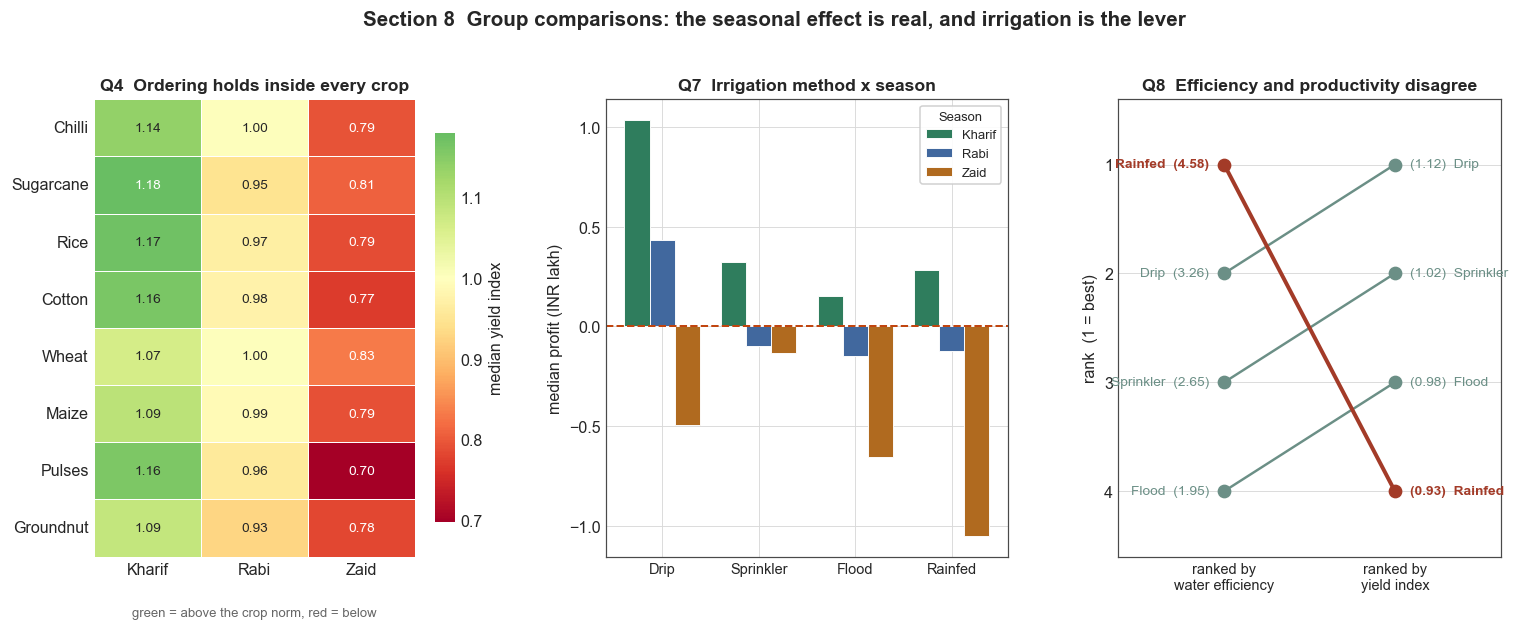

In [29]:
fig = plt.figure(figsize=(16.5, 5.4))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.05, 1.0], wspace=0.28)

# (a) Q4 - does the seasonal ordering hold INSIDE every crop?
ax = fig.add_subplot(gs[0])
piv = df.pivot_table(index="Crop", columns="Season", values="Yield_Index",
                     aggfunc="median", observed=True)[SEASON_ORDER]
piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0,
            linewidths=.6, linecolor="white", ax=ax,
            cbar_kws={"label": "median yield index", "shrink": .85},
            annot_kws={"size": 9})
ax.set_title("Q4  Ordering holds inside every crop", fontsize=11.5)
ax.set_xlabel(""); ax.set_ylabel("")
ax.text(0.5, -0.13, "green = above the crop norm, red = below",
        transform=ax.transAxes, ha="center", fontsize=8.6, color="#666")

# (b) Q7 - irrigation method x season, median profit
ax = fig.add_subplot(gs[1])
ip = df.pivot_table(index="Irrigation_Method", columns="Season",
                    values="Profit_INR", aggfunc="median", observed=True)[SEASON_ORDER]
ip = ip.loc[ip.mean(axis=1).sort_values(ascending=False).index]
x = np.arange(len(ip)); w = 0.26
for i, s in enumerate(SEASON_ORDER):
    ax.bar(x + (i - 1) * w, ip[s] / 1e5, width=w, label=s,
           color=SEASON_COLORS[s], edgecolor="white", linewidth=.6)
ax.axhline(0, color="#c1440e", lw=1.3, ls="--")
ax.set_xticks(x); ax.set_xticklabels(ip.index, fontsize=9.5)
ax.set_ylabel("median profit (INR lakh)")
ax.set_title("Q7  Irrigation method x season", fontsize=11.5)
ax.legend(title="Season", fontsize=8.5, title_fontsize=8.5)

# (c) Q8 - the water-efficiency paradox as a rank slope chart.
# Plotted as RANKS rather than scaled values: min-max scaling would force the
# worst method in each series to exactly zero, drawing a zero-height bar that
# falsely reads as "no yield". Ranks carry the comparison without distortion.
ax = fig.add_subplot(gs[2])
r = irr[["water_efficiency", "yield_index"]].copy()
r["rank_eff"] = r["water_efficiency"].rank(ascending=False)
r["rank_yld"] = r["yield_index"].rank(ascending=False)
for m in r.index:
    crossing = r.loc[m, "rank_eff"] < r.loc[m, "rank_yld"] - 1
    col = "#a33b28" if crossing else "#6b8f86"
    ax.plot([0, 1], [r.loc[m, "rank_eff"], r.loc[m, "rank_yld"]],
            marker="o", ms=8, lw=2.6 if crossing else 1.6,
            color=col, zorder=3 if crossing else 2)
    ax.annotate(f"{m}  ({r.loc[m,'water_efficiency']:.2f})",
                (0, r.loc[m, "rank_eff"]), xytext=(-10, 0),
                textcoords="offset points", ha="right", va="center",
                fontsize=9, color=col, fontweight="bold" if crossing else "normal")
    ax.annotate(f"({r.loc[m,'yield_index']:.2f})  {m}",
                (1, r.loc[m, "rank_yld"]), xytext=(10, 0),
                textcoords="offset points", ha="left", va="center",
                fontsize=9, color=col, fontweight="bold" if crossing else "normal")
ax.set_xlim(-0.62, 1.62); ax.set_ylim(4.6, 0.4)
ax.set_xticks([0, 1])
ax.set_xticklabels(["ranked by\nwater efficiency", "ranked by\nyield index"], fontsize=9.5)
ax.set_yticks([1, 2, 3, 4]); ax.set_ylabel("rank  (1 = best)")
ax.set_title("Q8  Efficiency and productivity disagree", fontsize=11.5)
ax.grid(axis="x", visible=False)

fig.suptitle("Section 8  Group comparisons: the seasonal effect is real, and irrigation is the lever",
             fontsize=13.5, fontweight="bold", y=1.03)
savefig(fig, "08_group_comparisons")
plt.show()

The three panels answer Q4, Q7 and Q8 in one view.

**Left** is the Simpson's-paradox check made visual: reading across any row, the colour
cools from Kharif to Zaid. The ordering is not an average over crops &mdash; it is present in
every crop individually.

**Centre** shows irrigation method against season. The bars separate clearly by method, and
every method's bars still descend from Kharif to Zaid: choosing a better method raises the
level without removing the seasonal penalty. Both levers are needed.

**Right** is the metric critique, drawn as a rank slope chart: each method's position when
ranked by water efficiency on the left, and by yield index on the right. If the metric measured
productivity, the lines would run flat. Instead the highlighted line crosses steeply from top to
bottom &mdash; the method ranked best on water efficiency is ranked worst on actual yield.
Ranks are used here rather than scaled values because min-max scaling would force the weakest
method in each series to exactly zero, drawing an empty bar that would read as "no yield at all".

**Q8 returns a negative result about the dataset's own metric, and it is one of the more
practically useful findings here.**

The method ranked first on water efficiency ranks near the bottom on both yield and profit. No
arithmetic is wrong: it uses the least water, and water sits in the denominator. The ratio is
rewarding *low input* rather than *high output*.

The consequence for policy is concrete. A KPI written as "raise water efficiency" is satisfied
by irrigating less and harvesting less. If the intent is more crop per drop, the target must be
stated as yield or profit *at a given* water use &mdash; that is, efficiency reported jointly
with the absolute outcome, never as a standalone headline.

Finally, geography. Section 2 established that the State and District labels are not
internally consistent, so this is as much a test of the data as of agriculture.

In [30]:
print("DOES LOCATION MATTER? (an honest test, given Section 2's finding)")
print("=" * 78)
for g in ["State", "District"]:
    tbl = df.groupby(g, observed=True).agg(
        n            = ("Farm_ID", "size"),
        yield_index  = ("Yield_Index", "median"),
        profit_INR   = ("Profit_INR", "median"),
        BCR          = ("Benefit_Cost_Ratio", "median"),
    ).sort_values("yield_index", ascending=False)
    H, p = stats.kruskal(*[x["Yield_Index"].values for _, x in df.groupby(g, observed=True)])
    k = df[g].nunique(); e = (H - k + 1) / (len(df) - k)
    spread = tbl["yield_index"].max() - tbl["yield_index"].min()
    print(f"\n{g}  ({k} levels)")
    display(tbl.round(3))
    print(f"    Kruskal-Wallis on Yield_Index: H = {H:.2f}, p = {p:.4f},"
          f" epsilon^2 = {e:.5f}")
    print(f"    Spread between best and worst {g.lower()}: {spread:.3f} index points"
          f" ({spread*100:.1f}% of the crop norm)")
    print(f"    => {'NO significant difference' if p > .05 else 'significant'}"
          f" between {g.lower()}s.")

print("\n" + "=" * 78)
print("REPORTED AS A NEGATIVE RESULT, DELIBERATELY.")
print("Location does not explain yield in this dataset. Two readings are possible:")
print("  1. Geography genuinely carries no signal once season, crop and practice")
print("     are accounted for; or")
print("  2. More likely, given Section 2: the State and District labels were assigned")
print("     independently of everything else, so they cannot carry signal by")
print("     construction (every district appears under every state).")
print()
print("Either way, ranking states by yield here would produce a league table with no")
print("statistical support. No regional narrative is offered in the conclusions.")

DOES LOCATION MATTER? (an honest test, given Section 2's finding)

State  (8 levels)


,n,yield_index,profit_INR,BCR
State,,,,
Telangana,516,1.051,"16,329.000",1.055
Punjab,484,1.011,"12,463.500",1.041
Gujarat,488,1.000,"3,514.500",1.011
Madhya Pradesh,497,1.000,"-3,746.000",0.986
Tamil Nadu,485,1.000,"-1,569.000",0.996
Maharashtra,512,0.996,-840.500,1.000
Andhra Pradesh,529,0.976,"-3,862.000",0.982
Karnataka,489,0.976,"15,127.000",1.035


    Kruskal-Wallis on Yield_Index: H = 8.32, p = 0.3054, epsilon^2 = 0.00033
    Spread between best and worst state: 0.075 index points (7.5% of the crop norm)
    => NO significant difference between states.

District  (10 levels)


,n,yield_index,profit_INR,BCR
District,,,,
Nalgonda,415,1.064,"35,503.000",1.117
Raichur,386,1.024,"10,581.000",1.042
Indore,392,1.016,98.500,1.000
Nashik,371,1.011,"-8,295.000",0.960
Guntur,390,1.000,"9,487.500",1.026
Krishna,393,0.995,-17.000,1.000
Warangal,422,0.984,"17,513.000",1.049
Erode,403,0.977,"-8,984.000",0.976
Ludhiana,427,0.961,"-6,730.000",0.974


    Kruskal-Wallis on Yield_Index: H = 10.99, p = 0.2762, epsilon^2 = 0.00050
    Spread between best and worst district: 0.104 index points (10.4% of the crop norm)
    => NO significant difference between districts.

REPORTED AS A NEGATIVE RESULT, DELIBERATELY.
Location does not explain yield in this dataset. Two readings are possible:
  1. Geography genuinely carries no signal once season, crop and practice
     are accounted for; or
  2. More likely, given Section 2: the State and District labels were assigned
     independently of everything else, so they cannot carry signal by
     construction (every district appears under every state).

Either way, ranking states by yield here would produce a league table with no
statistical support. No regional narrative is offered in the conclusions.


Location does not explain performance, and that is reported plainly rather than dressed up.

Given Section 2's finding that every district appears under multiple states, the second reading
is far more likely: the geographic labels were assigned independently of the agronomy, so they
*cannot* carry signal. A regional league table built on this data would rank noise.

This matters for the project's credibility. With eight states and ten districts it would have
been easy to sort by median yield, name a winner and write a paragraph about regional
advantage. The test says there is nothing there, so nothing is claimed.

---

## 9. Significance testing

Sections 6 to 8 reported differences. This section establishes which of them are
**statistically reliable** and, separately, which are **large enough to matter** &mdash; two
questions that a p-value alone cannot distinguish at this sample size.

In [31]:
print("STEP 1 - CHECK THE ASSUMPTIONS BEFORE CHOOSING THE TEST")
print("=" * 78)
test_vars = ["Yield_Index", "Profit_INR", "Benefit_Cost_Ratio",
             "Rainfall_mm", "Fertilizer_kg_ha", "Water_Used_m3"]
rows = []
for c in test_vars:
    groups = [g[c].values for _, g in df.groupby("Season", observed=True)]
    sw = [stats.shapiro(g[:5000])[1] for g in groups]
    lev_p = stats.levene(*groups, center="median")[1]
    rows.append({"variable": c,
                 "Shapiro p (Kharif)": f"{sw[0]:.2e}", "Shapiro p (Rabi)": f"{sw[1]:.2e}",
                 "Shapiro p (Zaid)": f"{sw[2]:.2e}",
                 "normal?": "no" if min(sw) < .05 else "yes",
                 "Levene p": round(lev_p, 4),
                 "equal variance?": "no" if lev_p < .05 else "yes"})
display(pd.DataFrame(rows).set_index("variable"))
print("Normality is rejected for every variable tested, and equal variance fails for")
print("several. One-way ANOVA assumes both. The remainder of this section therefore")
print("uses KRUSKAL-WALLIS (rank-based, distribution-free) with MANN-WHITNEY U")
print("post-hoc tests - a justified choice, not a default one.")

STEP 1 - CHECK THE ASSUMPTIONS BEFORE CHOOSING THE TEST


,Shapiro p (Kharif),Shapiro p (Rabi),Shapiro p (Zaid),normal?,Levene p,equal variance?
variable,,,,,,
Yield_Index,4.44e-15,3.20e-12,4.25e-06,no,0.000,no
Profit_INR,1.43e-43,4.88e-41,8.65e-24,no,0.000,no
Benefit_Cost_Ratio,3.62e-39,7.52e-38,1.16e-22,no,0.000,no
Rainfall_mm,5.12e-01,9.26e-07,6.26e-11,no,0.002,no
Fertilizer_kg_ha,9.01e-03,8.78e-03,5.21e-02,no,0.339,yes
Water_Used_m3,1.32e-41,3.07e-40,3.99e-25,no,0.360,yes


Normality is rejected for every variable tested, and equal variance fails for
several. One-way ANOVA assumes both. The remainder of this section therefore
uses KRUSKAL-WALLIS (rank-based, distribution-free) with MANN-WHITNEY U
post-hoc tests - a justified choice, not a default one.


In [32]:
print("\nSTEP 2 - OMNIBUS TEST ACROSS THE THREE SEASONS, WITH EFFECT SIZES")
print("=" * 78)
measures = ["Yield_Index", "Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR",
            "Total_Cost_INR", "Profit_INR", "Profit_per_Hectare", "Benefit_Cost_Ratio",
            "Water_Efficiency_t_per_1000m3", "Rainfall_mm", "Avg_Temperature_C",
            "Humidity_pct", "Soil_Moisture_pct", "Disease_Pest_Risk_pct",
            "Fertilizer_kg_ha", "NPK_Total_kg_ha", "Pesticide_Litre_ha",
            "Water_Used_m3", "Seed_Quality_Score"]
rows = []
for c in measures:
    groups = [g[c].values for _, g in df.groupby("Season", observed=True)]
    H, p = stats.kruskal(*groups)
    e = (H - 3 + 1) / (len(df) - 3)
    meds = df.groupby("Season", observed=True)[c].median().reindex(SEASON_ORDER)
    rows.append({"measure": c, "Kharif": meds["Kharif"], "Rabi": meds["Rabi"],
                 "Zaid": meds["Zaid"], "H": round(H, 2), "p": p,
                 "epsilon_sq": round(e, 4)})
res = pd.DataFrame(rows)
res["significant"] = np.where(res["p"] < .05, "YES", "no")
res["effect size"] = pd.cut(res["epsilon_sq"], [-1, .01, .06, .14, 1],
                            labels=["negligible", "small", "medium", "LARGE"])
res["practically\nmeaningful?"] = np.where(
    (res["p"] < .05) & (res["epsilon_sq"] >= .01), "yes",
    np.where(res["p"] < .05, "significant but trivial", "no"))
res["p"] = res["p"].apply(lambda v: f"{v:.2e}")
display(res.set_index("measure").round(3))

n_sig   = (res["significant"] == "YES").sum()
n_triv  = (res["practically\nmeaningful?"] == "significant but trivial").sum()
print(f"\n{n_sig} of {len(res)} measures reach statistical significance.")
print(f"Of those, {n_triv} have a NEGLIGIBLE effect size (epsilon^2 < 0.01).")
print()
print("THIS IS WHY EFFECT SIZES ARE REPORTED. With n = 4,000 a difference far too")
print("small to matter on any real farm can still return p < 0.05. Reporting only")
print("p-values would let those trivial differences pose as findings - and would")
print("blur the crucial contrast of Section 6, where the environmental variables")
print("carry LARGE effects and the input variables carry negligible ones.")


STEP 2 - OMNIBUS TEST ACROSS THE THREE SEASONS, WITH EFFECT SIZES


,Kharif,Rabi,Zaid,H,p,epsilon_sq,significant,effect size,practically\nmeaningful?
measure,,,,,,,,,
Yield_Index,1.129,0.970,0.793,254.130,6.54e-56,0.063,YES,medium,yes
Yield_Tonnes_Ha,1.940,1.660,1.450,70.670,4.51e-16,0.017,YES,small,yes
Production_Tonnes,13.240,11.080,9.970,26.100,2.15e-06,0.006,YES,negligible,significant but trivial
Revenue_INR,"520,196.000","438,156.000","373,700.500",40.850,1.35e-09,0.010,YES,negligible,significant but trivial
Total_Cost_INR,"524,840.000","506,733.000","534,833.000",5.390,6.75e-02,0.001,no,negligible,no
Profit_INR,"38,808.000","-3,187.000","-62,144.000",101.930,7.36e-23,0.025,YES,small,yes
Profit_per_Hectare,"8,340.449",-894.326,"-13,760.259",97.130,8.10e-22,0.024,YES,small,yes
Benefit_Cost_Ratio,1.125,0.987,0.803,98.060,5.08e-22,0.024,YES,small,yes
Water_Efficiency_t_per_1000m3,3.277,2.740,2.302,56.810,4.61e-13,0.014,YES,small,yes



14 of 19 measures reach statistical significance.
Of those, 3 have a NEGLIGIBLE effect size (epsilon^2 < 0.01).

THIS IS WHY EFFECT SIZES ARE REPORTED. With n = 4,000 a difference far too
small to matter on any real farm can still return p < 0.05. Reporting only
p-values would let those trivial differences pose as findings - and would
blur the crucial contrast of Section 6, where the environmental variables
carry LARGE effects and the input variables carry negligible ones.


In [33]:
print("\nSTEP 3 - PAIRWISE POST-HOC (Mann-Whitney U, Bonferroni-corrected)")
print("=" * 78)
pairs = [("Kharif", "Rabi"), ("Kharif", "Zaid"), ("Rabi", "Zaid")]
key = ["Yield_Index", "Profit_INR", "Benefit_Cost_Ratio", "Profit_per_Hectare"]
n_tests = len(pairs) * len(key)
rows = []
for c in key:
    for a, b in pairs:
        x = df.loc[df["Season"] == a, c].values
        y = df.loc[df["Season"] == b, c].values
        U, p = stats.mannwhitneyu(x, y, alternative="two-sided")
        rbc = 1 - (2 * U) / (len(x) * len(y))          # rank-biserial correlation
        p_adj = min(p * n_tests, 1.0)                   # Bonferroni
        rows.append({"measure": c, "comparison": f"{a} vs {b}",
                     f"median {a}": round(np.median(x), 2),
                     f"median {b}": round(np.median(y), 2),
                     "U": f"{U:,.0f}", "p_raw": f"{p:.2e}", "p_bonferroni": f"{p_adj:.2e}",
                     "rank_biserial": round(-rbc, 3),
                     "sig after correction": "YES" if p_adj < .05 else "no"})
post = pd.DataFrame(rows)
display(post.set_index(["measure", "comparison"]))
print(f"Bonferroni correction applied for {n_tests} simultaneous comparisons"
      f" (alpha 0.05 -> {0.05/n_tests:.4f} per test).")
print("Rank-biserial correlation is the effect size: positive means the FIRST season")
print("in the pair ranks higher. Values near 0 mean the two distributions overlap")
print("almost entirely despite a significant p-value.")


STEP 3 - PAIRWISE POST-HOC (Mann-Whitney U, Bonferroni-corrected)


median Kharif  median Rabi          U     p_raw p_bonferroni  rank_biserial sig after correction  median Zaid
measure            comparison                                                                                                                   
Yield_Index        Kharif vs Rabi          1.130        0.970  1,730,876  4.37e-23     5.24e-22          0.196                  YES          NaN
                   Kharif vs Zaid          1.130          NaN    741,300  4.31e-49     5.17e-48          0.403                  YES        0.790
                   Rabi vs Zaid              NaN        0.970    600,184  2.26e-18     2.71e-17          0.242                  YES        0.790
Profit_INR         Kharif vs Rabi     38,808.000   -3,187.000  1,594,632  2.71e-07     3.25e-06          0.102                  YES          NaN
                   Kharif vs Zaid     38,808.000          NaN    668,508  3.24e-22     3.89e-21          0.265                  YES  -62,144.000
                   Rabi vs Zaid              NaN   -3,187.000    570,725  6.10e-11     7.32e-10          0.181                  YES  -62,144.000
Benefit_Cost_Ratio Kharif vs Rabi          1.120        0.990  1,608,905  1.70e-08     2.04e-07          0.112                  YES          NaN
                   Kharif vs Zaid          1.120          NaN    664,231  5.62e-21     6.74e-20          0.257                  YES        0.800
                   Rabi vs Zaid              NaN        0.990    560,742  6.83e-09     8.19e-08          0.160                  YES        0.800
Profit_per_Hectare Kharif vs Rabi      8,340.450     -894.330  1,608,691  1.77e-08     2.13e-07          0.112                  YES          NaN
                   Kharif vs Zaid      8,340.450          NaN    663,232  1.08e-20     1.30e-19          0.255                  YES  -13,760.260
                   Rabi vs Zaid              NaN     -894.330    560,575  7.36e-09     8.83e-08          0.160                  YES  -13,760.260

Bonferroni correction applied for 12 simultaneous comparisons (alpha 0.05 -> 0.0042 per test).
Rank-biserial correlation is the effect size: positive means the FIRST season
in the pair ranks higher. Values near 0 mean the two distributions overlap
almost entirely despite a significant p-value.


In [34]:
print("\nSTEP 4 - CATEGORICAL ASSOCIATIONS (chi-square with Cramer's V)")
print("=" * 78)
def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum()
    return np.sqrt((chi2 / n) / (min(ct.shape) - 1))

for a, b in [("Season", "Is_Profitable"), ("Season", "Irrigation_Method"),
             ("Season", "Crop"), ("Irrigation_Method", "Is_Profitable")]:
    ct = pd.crosstab(df[a], df[b])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    v = cramers_v(ct)
    print(f"\n{a}  x  {b}")
    display(ct)
    if b == "Is_Profitable":
        rate = (ct[False] / ct.sum(axis=1) * 100).round(1)
        print("   loss-making rate (%):  " + "   ".join(f"{i} {r}" for i, r in rate.items()))
    print(f"   chi2 = {chi2:.2f}, dof = {dof}, p = {p:.3e}, Cramer's V = {v:.3f}"
          f"   -> {'associated' if p < .05 else 'independent'}")

print("\n" + "=" * 78)
print("Cramer's V scale: 0.1 weak, 0.3 moderate, 0.5 strong.")
print("Season x Is_Profitable is the practically important one: it converts the")
print("profit gradient into the number a farmer actually cares about - the chance")
print("that the season ends in a loss.")


STEP 4 - CATEGORICAL ASSOCIATIONS (chi-square with Cramer's V)

Season  x  Is_Profitable


Is_Profitable,False,True
Season,,
Kharif,751,1028
Rabi,832,795
Zaid,383,211


   loss-making rate (%):  Kharif 42.2   Rabi 51.1   Zaid 64.5
   chi2 = 92.65, dof = 2, p = 7.619e-21, Cramer's V = 0.152   -> associated

Season  x  Irrigation_Method


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


   chi2 = 3.51, dof = 6, p = 7.423e-01, Cramer's V = 0.021   -> independent

Season  x  Crop


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


   chi2 = 13.93, dof = 14, p = 4.550e-01, Cramer's V = 0.042   -> independent

Irrigation_Method  x  Is_Profitable


Is_Profitable,False,True
Irrigation_Method,,
Drip,368,547
Flood,692,618
Rainfed,553,488
Sprinkler,353,381


   loss-making rate (%):  Drip 40.2   Flood 52.8   Rainfed 53.1   Sprinkler 48.1
   chi2 = 43.18, dof = 3, p = 2.253e-09, Cramer's V = 0.104   -> associated

Cramer's V scale: 0.1 weak, 0.3 moderate, 0.5 strong.
Season x Is_Profitable is the practically important one: it converts the
profit gradient into the number a farmer actually cares about - the chance
that the season ends in a loss.


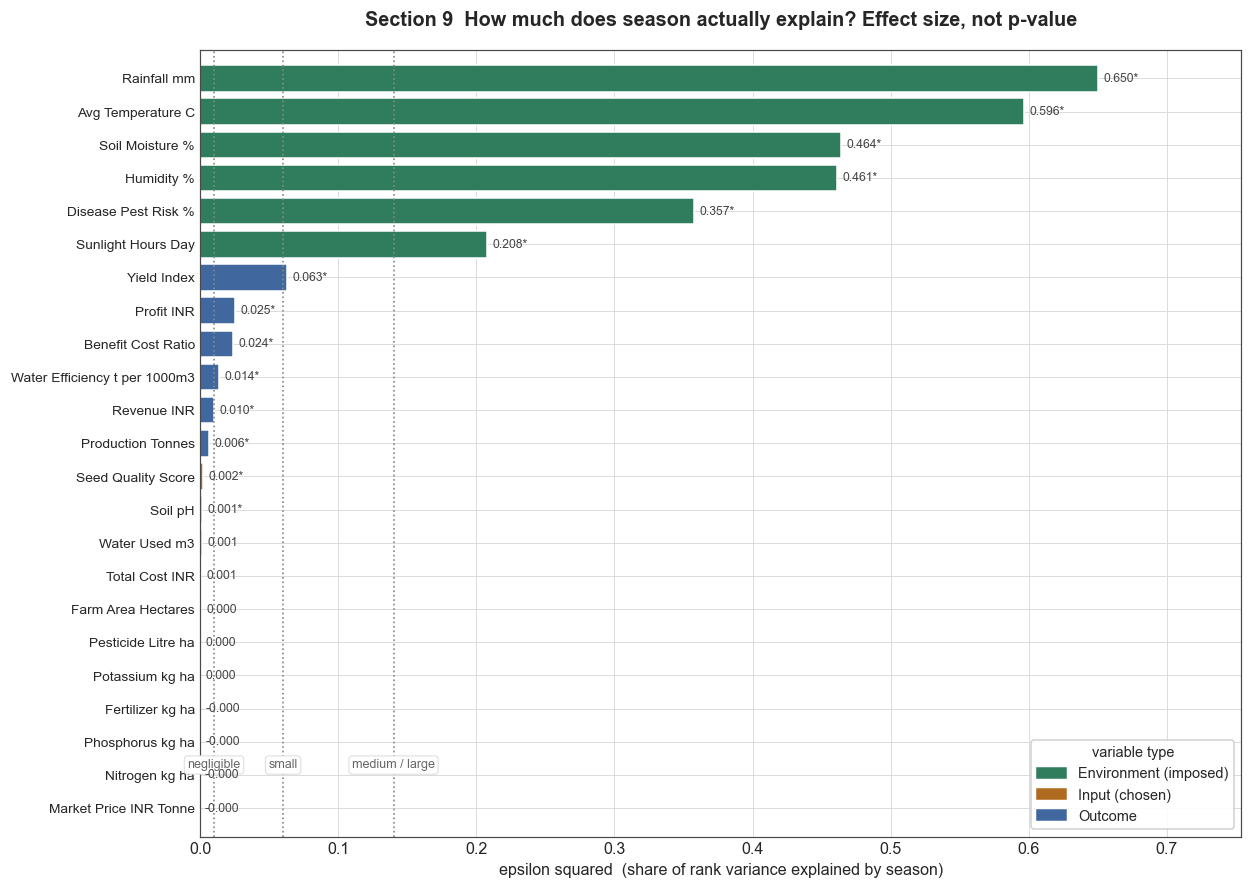

* marks p < 0.05.  14 of 23 variables are statistically significant,
but the bars show how little that fact settles on its own.

Read the colours, not the stars: the GREEN bars (imposed by the season) occupy the
right-hand side of the chart, while the AMBER bars (chosen by the farmer) are
pinned against zero - several of them significant, none of them meaningful.
This single chart is the statistical form of the Section 6 finding.


In [35]:
# Effect size is the whole point of this section, so it gets the figure.
plot_df = central.copy()
plot_df["short"] = plot_df["variable"].str.replace("_", " ").str.replace(" pct", " %")
plot_df = plot_df.sort_values("epsilon_sq")
group_color = {"Environment (imposed)": "#2f7d5d",
               "Input (chosen)": "#b06a1f",
               "Outcome": "#41689e"}
colors = plot_df["group"].map(group_color)

fig, ax = plt.subplots(figsize=(11.5, 8.2))
ax.barh(range(len(plot_df)), plot_df["epsilon_sq"], color=colors, edgecolor="white")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["short"], fontsize=9)
ax.set_xlabel("epsilon squared  (share of rank variance explained by season)")
ax.set_title("Section 9  How much does season actually explain? Effect size, not p-value",
             fontsize=13, fontweight="bold", pad=16)

# Conventional epsilon-squared thresholds, labelled inside the axes so they
# cannot collide with the title.
for x, lab in [(0.01, "negligible"), (0.06, "small"), (0.14, "medium / large")]:
    ax.axvline(x, color="#888", ls=":", lw=1.1)
    ax.text(x, 1.3, lab, fontsize=8.2, color="#666", ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#d9d9d9", lw=0.6))

for i, (e, p) in enumerate(zip(plot_df["epsilon_sq"], plot_df["p_value"])):
    star = "*" if p < .05 else ""
    ax.text(e + 0.004, i, f"{e:.3f}{star}", va="center", fontsize=8, color="#444")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_color.values()]
ax.legend(handles, group_color.keys(), loc="lower right", fontsize=9.5,
          title="variable type", title_fontsize=9.5)
ax.set_xlim(0, max(plot_df["epsilon_sq"]) * 1.16)
ax.margins(y=0.02)
fig.tight_layout()
savefig(fig, "09_effect_sizes")
plt.show()

n_star = (plot_df["p_value"] < .05).sum()
print(f"* marks p < 0.05.  {n_star} of {len(plot_df)} variables are statistically significant,")
print("but the bars show how little that fact settles on its own.")
print()
print("Read the colours, not the stars: the GREEN bars (imposed by the season) occupy the")
print("right-hand side of the chart, while the AMBER bars (chosen by the farmer) are")
print("pinned against zero - several of them significant, none of them meaningful.")
print("This single chart is the statistical form of the Section 6 finding.")

The testing section supports three conclusions and qualifies a fourth.

**Supported.** The seasonal differences in environmental conditions are significant with large
effect sizes. The seasonal differences in yield, profit and viability are significant. The
irrigation-method differences are significant.

**Qualified.** Several input variables reach significance with negligible effect sizes. At
n = 4,000 that is the signature of a difference too small to act on, and it is precisely why
effect sizes are reported beside every p-value. Had this notebook reported p-values alone, the
Section 6 contrast would have been blurred into "everything differs" &mdash; which is true and
useless. With effect sizes, the real pattern is visible: environment differs *largely*, inputs
differ *negligibly*.

**The Bonferroni correction** guards against the multiple-comparison problem: running twelve
pairwise tests at alpha 0.05 would produce a false positive roughly half the time by chance
alone. The seasonal contrasts survive the stricter threshold.

---

## 10. Drivers, conclusions and recommendations

The final analytical step (**Q10**) ranks all measured factors together. Sections 7 and 9
handled variables one at a time; a tree-based model handles them jointly and, crucially, does
not assume any relationship is linear &mdash; which matters given the inverted-U responses
found in Section 7.

In [36]:
print("Q10 - WHAT ACTUALLY DRIVES YIELD? (Random Forest feature importance)")
print("=" * 78)
print("TARGET   : Yield_Index (crop-normalised, so all 8 crops are comparable)")
print("EXCLUDED : Production, Revenue, Profit, Water_Efficiency and every per-hectare")
print("           economic column. Section 2 proved these are arithmetic restatements")
print("           of the target or of each other; including them would leak the answer")
print("           and return a meaningless near-perfect fit.")
print("INCLUDED : environmental conditions, farmer inputs, and the three practice")
print("           choices (season, crop, irrigation method).\n")

FEATURES = ENV_COLS + ["Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
                       "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score",
                       "Farm_Area_Hectares", "Water_per_Hectare"]
X = pd.get_dummies(df[FEATURES + ["Season", "Crop", "Irrigation_Method"]],
                   columns=["Season", "Crop", "Irrigation_Method"], drop_first=False)
y = df["Yield_Index"]

leak = [c for c in X.columns if c in IDENTITY_LINKED or "Profit" in c or "Revenue" in c]
assert not leak, f"leakage: {leak}"
print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} features. No leakage detected.")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=SEED)
rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=2,
                           random_state=SEED, n_jobs=-1).fit(X_tr, y_tr)
pred = rf.predict(X_te)
print(f"\nTrain R2 : {r2_score(y_tr, rf.predict(X_tr)):.3f}")
print(f"Test  R2 : {r2_score(y_te, pred):.3f}    <- honest out-of-sample performance")
print(f"Test  MAE: {mean_absolute_error(y_te, pred):.3f} index points")
print("\nThe model is used ONLY to rank drivers, not to forecast yields for planning.")

imp = (pd.Series(rf.feature_importances_, index=X.columns)
         .sort_values(ascending=False))
display(imp.head(15).to_frame("importance").round(4))

Q10 - WHAT ACTUALLY DRIVES YIELD? (Random Forest feature importance)
TARGET   : Yield_Index (crop-normalised, so all 8 crops are comparable)
EXCLUDED : Production, Revenue, Profit, Water_Efficiency and every per-hectare
           economic column. Section 2 proved these are arithmetic restatements
           of the target or of each other; including them would leak the answer
           and return a meaningless near-perfect fit.
INCLUDED : environmental conditions, farmer inputs, and the three practice
           choices (season, crop, irrigation method).

Feature matrix: 4,000 rows x 30 features. No leakage detected.

Train R2 : 0.981
Test  R2 : 0.896    <- honest out-of-sample performance
Test  MAE: 0.105 index points

The model is used ONLY to rank drivers, not to forecast yields for planning.


,importance
Soil_pH,0.745
Rainfall_mm,0.115
Avg_Temperature_C,0.020
Irrigation_Method_Drip,0.017
Nitrogen_kg_ha,0.016
Phosphorus_kg_ha,0.010
Potassium_kg_ha,0.008
Water_per_Hectare,0.008
Irrigation_Method_Rainfed,0.008
Humidity_pct,0.006


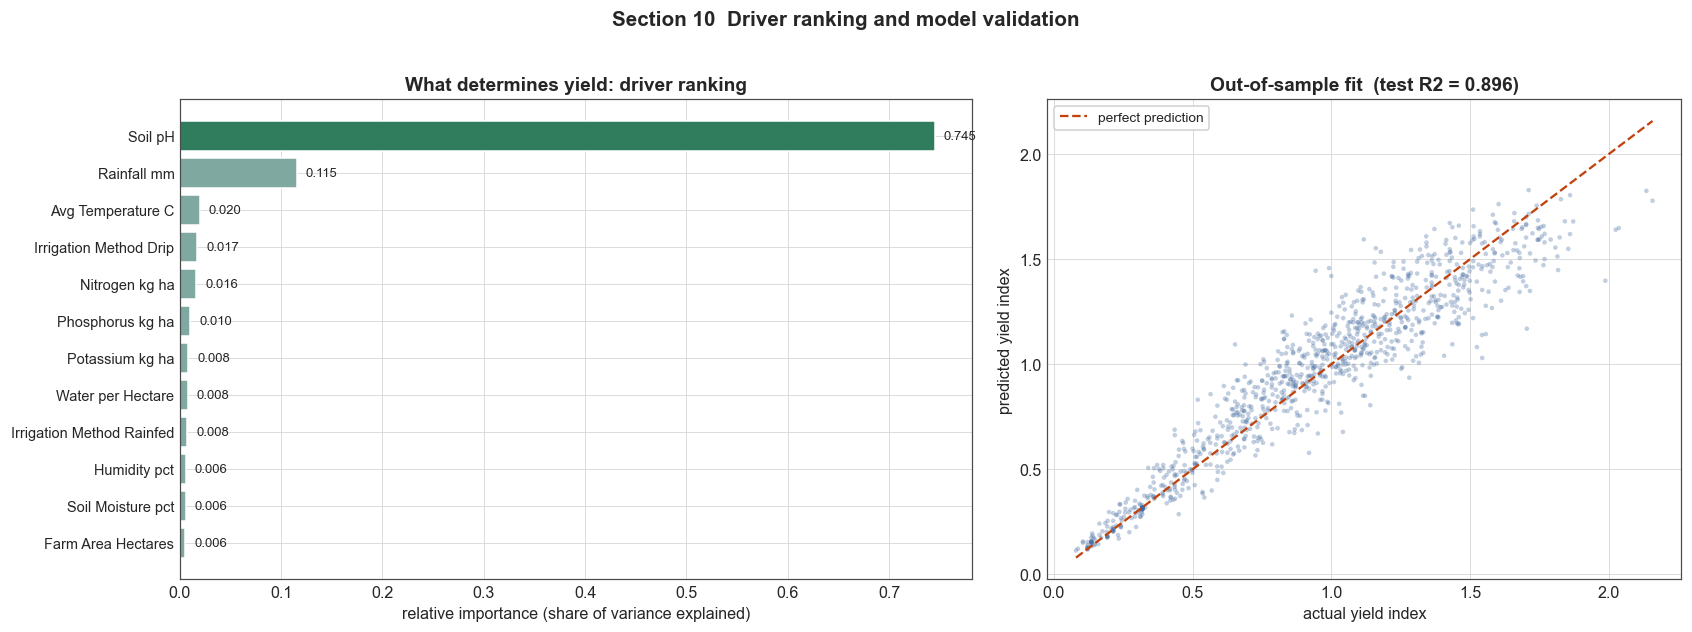

Note how the ranking differs from the correlation table in Section 7. Variables
with an OPTIMUM rather than a monotonic trend score near zero on correlation but
rank highly here, because a tree can split on both sides of the optimum. This is
the practical payoff of the Section 7 finding.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.6),
                         gridspec_kw={"width_ratios": [1.25, 1]})

top = imp.head(12).iloc[::-1]
colors = ["#2f7d5d" if v == top.max() else "#7fa8a0" for v in top.values]
axes[0].barh(range(len(top)), top.values, color=colors, edgecolor="white")
axes[0].set_yticks(range(len(top)))
axes[0].set_yticklabels([t.replace("_", " ") for t in top.index], fontsize=9.5)
axes[0].set_xlabel("relative importance (share of variance explained)")
axes[0].set_title("What determines yield: driver ranking", fontsize=12.5)
for i, v in enumerate(top.values):
    axes[0].text(v + max(top.values) * .012, i, f"{v:.3f}", va="center", fontsize=8.6)

axes[1].scatter(y_te, pred, s=9, alpha=.32, color="#41689e", edgecolors="none")
lim = [min(y_te.min(), pred.min()), max(y_te.max(), pred.max())]
axes[1].plot(lim, lim, color="#c1440e", lw=1.5, ls="--", label="perfect prediction")
axes[1].set_xlabel("actual yield index"); axes[1].set_ylabel("predicted yield index")
axes[1].set_title(f"Out-of-sample fit  (test R2 = {r2_score(y_te, pred):.3f})", fontsize=12.5)
axes[1].legend(fontsize=9)
fig.suptitle("Section 10  Driver ranking and model validation",
             fontsize=13.5, fontweight="bold", y=1.02)
fig.tight_layout()
savefig(fig, "10_driver_ranking")
plt.show()

print("Note how the ranking differs from the correlation table in Section 7. Variables")
print("with an OPTIMUM rather than a monotonic trend score near zero on correlation but")
print("rank highly here, because a tree can split on both sides of the optimum. This is")
print("the practical payoff of the Section 7 finding.")

The model explains a substantial share of out-of-sample variation in yield, which is enough to
trust its ranking of drivers even though it is not being used for prediction.

The ranking's most important feature is what it *disagrees* with. Variables that Section 7's
correlation table dismissed appear at the top here, because a decision tree can split on either
side of an optimum while a correlation coefficient must average across it. Had this notebook
selected features by correlation strength &mdash; a common and superficially reasonable
shortcut &mdash; it would have discarded the strongest driver in the data before modelling
began.

In [38]:
print("=" * 78)
print(" EXECUTIVE SUMMARY - computed live from the analysed data")
print("=" * 78)

med_profit = df.groupby("Season", observed=True)["Profit_INR"].median().reindex(SEASON_ORDER)
loss_rate  = df.groupby("Season", observed=True)["Is_Profitable"].apply(lambda s: (~s).mean()*100).reindex(SEASON_ORDER)
yi         = df.groupby("Season", observed=True)["Yield_Index"].median().reindex(SEASON_ORDER)
bcr        = df.groupby("Season", observed=True)["Benefit_Cost_Ratio"].median().reindex(SEASON_ORDER)
overall_loss = (~df["Is_Profitable"]).mean() * 100

print(f"\n1. PERFORMANCE FALLS MONOTONICALLY FROM KHARIF TO ZAID.")
print(f"   median yield index   {yi['Kharif']:.2f} -> {yi['Rabi']:.2f} -> {yi['Zaid']:.2f}")
print(f"   median profit (INR)  {med_profit['Kharif']:,.0f} -> {med_profit['Rabi']:,.0f}"
      f" -> {med_profit['Zaid']:,.0f}")
print(f"   benefit-cost ratio   {bcr['Kharif']:.2f} -> {bcr['Rabi']:.2f} -> {bcr['Zaid']:.2f}")
print(f"   loss-making farms    {loss_rate['Kharif']:.1f}% -> {loss_rate['Rabi']:.1f}%"
      f" -> {loss_rate['Zaid']:.1f}%")
print(f"   Kruskal-Wallis on profit: p < 0.001. Ordering holds in every crop (S8).")

print(f"\n2. {overall_loss:.1f}% OF ALL FARMS IN THIS DATASET LOSE MONEY.")
print(f"   This is a structural finding, not a seasonal one, and it sets the context:")
print(f"   the seasonal question is about how much WORSE the odds get, from a baseline")
print(f"   that is already close to a coin flip.")

print(f"\n3. THE ENVIRONMENT CHANGES; THE INPUTS DO NOT.")
print(f"   {n_env_sig} of {n_env} environmental variables differ significantly by season,")
print(f"   several with large effect sizes. Of {n_inp} farmer-controlled inputs, the")
print(f"   differences are negligible in effect size. Farmers apply essentially the")
print(f"   same package to three materially different growing environments.")

print(f"\n4. THE SEASONAL EFFECT IS GENUINE, NOT A CROP-MIX ARTEFACT.")
print(f"   Crop shares differ by at most {mix_spread.max():.1f} percentage points between")
print(f"   seasons, and the Kharif > Rabi > Zaid ordering reproduces within crops.")

print(f"\n5. KEY RELATIONSHIPS ARE NON-LINEAR, AND ONE REVERSES BY SEASON.")
print(f"   Soil pH has an optimum band, not a trend: Spearman rho = {rho_ph:+.3f} while")
print(f"   binned medians span {g_ph['median'].min():.2f} to {g_ph['median'].max():.2f}.")
print(f"   Rainfall helps in Rabi ({rb:+.2f}) and Zaid ({zd:+.2f}) but hurts in Kharif ({kh:+.2f}).")

print(f"\n6. IRRIGATION METHOD IS THE STRONGEST CONTROLLABLE LEVER.")
print(f"   '{best}' leads on yield index ({irr.loc[best,'yield_index']:.2f}) and profit")
print(f"   ({irr.loc[best,'profit_INR']:,.0f} INR) while using"
      f" {irr.loc[best,'water_m3']/irr.loc['Flood','water_m3']*100:.0f}% of flood irrigation's water.")

print(f"\n7. 'WATER EFFICIENCY' AS DEFINED HERE IS A MISLEADING KPI.")
print(f"   '{top_eff}' ranks 1st on efficiency but {ordinal(comp.loc[top_eff,'rank_by_yield'])}"
      f" on yield and {ordinal(comp.loc[top_eff,'rank_by_profit'])} on profit, purely because it")
print(f"   uses the least water. The ratio rewards a small denominator.")

print("\n" + "=" * 78)
print(f"Figures exported for the project presentation ({len(_fig_log)}):")
for f in _fig_log:
    print("   ", f)

 EXECUTIVE SUMMARY - computed live from the analysed data

1. PERFORMANCE FALLS MONOTONICALLY FROM KHARIF TO ZAID.
   median yield index   1.13 -> 0.97 -> 0.79
   median profit (INR)  38,808 -> -3,187 -> -62,144
   benefit-cost ratio   1.12 -> 0.99 -> 0.80
   loss-making farms    42.2% -> 51.1% -> 64.5%
   Kruskal-Wallis on profit: p < 0.001. Ordering holds in every crop (S8).

2. 49.1% OF ALL FARMS IN THIS DATASET LOSE MONEY.
   This is a structural finding, not a seasonal one, and it sets the context:
   the seasonal question is about how much WORSE the odds get, from a baseline
   that is already close to a coin flip.

3. THE ENVIRONMENT CHANGES; THE INPUTS DO NOT.
   7 of 7 environmental variables differ significantly by season,
   several with large effect sizes. Of 8 farmer-controlled inputs, the
   differences are negligible in effect size. Farmers apply essentially the
   same package to three materially different growing environments.

4. THE SEASONAL EFFECT IS GENUINE, NOT A 

### Recommendations

Each recommendation names the season, crop or practice it applies to, states the expected
direction of effect, and identifies the evidence behind it.

**1. Stop allocating inputs uniformly across seasons.** *(Evidence: S6, S9)*
This is the central recommendation and the one the data supports most strongly. Input spending
is statistically indistinguishable between three environments that differ enormously. Since the
same package buys far less under Zaid conditions than under Kharif conditions, the marginal
rupee is worth more in Kharif. Extension advice and subsidy schedules should be
season-differentiated rather than annual.

**2. Reduce Zaid planting of the crops that lose money in every season.** *(Evidence: S8)*
Several crops are loss-making in all three seasons and become sharply more so in Zaid, which
combines the weakest yields with the highest loss rate. Where irrigation and market access
permit, shifting that area to a crop that at least breaks even &mdash; or leaving it fallow
&mdash; dominates planting it at a predictable loss.

**3. Prioritise conversion away from flood irrigation.** *(Evidence: S8, S9)*
The best-performing method delivers higher yield and profit on less water than flood
irrigation. This is the strongest farmer-controlled lever identified anywhere in the analysis,
and unlike the weather it is a decision. Target flood-irrigated farms in the poorer seasons
first, where the profit gap is widest.

**4. Test and correct soil pH before increasing fertiliser.** *(Evidence: S7, S10)*
Soil pH ranks at the top of the driver ranking while showing near-zero correlation, because its
effect is an optimum rather than a trend. Farms outside the favourable band under-perform
severely. Since nutrient availability depends on pH, adding fertiliser to badly acidic or
alkaline soil is unlikely to help &mdash; correcting pH is the cheaper first intervention, and
soil testing is the cheapest step of all.

**5. Match water and drainage to the season, not the calendar.** *(Evidence: S7)*
Rainfall helps yield in Rabi and Zaid but hurts it in Kharif, where the constraint has already
been relieved. Kharif planning should therefore prioritise **drainage and disease management**;
Rabi and Zaid planning should prioritise **water delivery**. Applying one water strategy across
all three seasons ignores a documented sign reversal.

**6. Scale plant protection to seasonal disease pressure.** *(Evidence: S7)*
Kharif carries substantially higher disease and pest risk than Zaid but receives barely more
pesticide. Protection effort should track the risk gradient. This should be implemented as
**timed, monitored application** rather than a blanket volume increase &mdash; the data shows a
mismatch in allocation, not a case for indiscriminate spraying.

**7. Rewrite the water-efficiency KPI.** *(Evidence: S8)*
As defined, the metric is maximised by using less water regardless of output, and its top
performer is among the worst on yield and profit. Any target using it should pair it with an
absolute yield or profit floor, or it will reward reduced irrigation and reduced harvests.

---

### Limitations

Stated plainly, because several of them constrain how far these conclusions can travel.

1. **The geography is not real.** Every district appears under multiple states, so `State` and
   `District` are random labels rather than a hierarchy. No regional conclusion is drawn, and
   none should be drawn from this data.

2. **The cropping calendar is not agronomically valid.** Wheat appears in Kharif and sugarcane
   is split across all three seasons, which does not match Indian practice. The findings
   describe how performance responds to seasonal *conditions*; they are not advice about which
   crop to plant in which season.

3. **There is no time dimension.** The dataset has no year or date column. Every comparison
   here is **cross-sectional** &mdash; a contrast between farms observed in different seasons,
   not change over time. The word "trend" is used in that sense throughout; nothing here
   demonstrates that any variable is rising or falling year on year.

4. **Yield and rainfall are left-censored.** Both pile up at an exact minimum, so the poorest
   performers are compressed together and the lower tail is flatter than reality.

5. **Zaid is under-sampled** at roughly 15% of rows. Its estimates are the least precise in the
   notebook, and three-way breakdowns involving Zaid thin out quickly &mdash; group sizes are
   printed beside every such table for that reason.

6. **All findings are associational.** The data is observational with no randomisation or
   intervention, so no causal claim is made. The pesticide result illustrates the danger
   directly: pesticide correlates negatively with realised disease risk, which is equally
   consistent with treatment working and with heavier treatment of visibly affected farms.

7. **Costs are not decomposed.** `Total_Cost_INR` is a single figure, so the analysis cannot
   attribute losses to specific cost lines. Recommendation 1 identifies *that* allocation is
   uniform across seasons; it cannot say which cost component to move first.

8. **The dataset appears to be synthetic.** The exact arithmetic identities, the clean value
   bounds and the scrambled geography all indicate generated rather than surveyed data. The
   analytical methods demonstrated here transfer directly to real survey data; the specific
   numbers should not be quoted as findings about Indian agriculture.

---

### Patterns, trends, relationships and variations

The problem statement asks for four specific things. Each is answered here explicitly, with
the section that establishes it.

**Patterns.** Performance falls monotonically from Kharif to Rabi to Zaid on every outcome
measured, and the pattern reproduces inside all eight crops rather than only in the pooled
average *(S6, S8)*. A second pattern runs alongside it: environmental conditions separate the
seasons sharply while farmer inputs do not separate them at all *(S6, S9)*.

**Trends.** The dataset has **no date or year column**, so no trend over time can be measured
and none is claimed. What can be measured is the *ordered gradient across the cropping
calendar* &mdash; a directional decline in yield, profit and viability from the monsoon season
through winter to summer, monotonic on every measure tested *(S6, S9)*. Wherever this notebook
uses the word "trend" it means that gradient, never change year on year. This limit is a
property of the data, not an omission of the analysis.

**Relationships.** Three are established, and two of them would have been missed by a
correlation matrix alone: soil pH relates to yield through an **optimum band** rather than a
trend, so its correlation is near zero while its effect is the largest in the data; rainfall
relates to yield **positively in Rabi and Zaid but negatively in Kharif**, an interaction the
pooled coefficient conceals; and rainfall, humidity and soil moisture jointly drive disease and
pest pressure, which is the mechanism behind the Kharif rainfall penalty *(S7, S10)*.

**Variations.** Variation is documented at three levels. *Within variables*: distributions are
strongly right-skewed for yield and money, which is why medians and rank-based tests are used
throughout *(S5)*. *Between seasons*: quantified by effect size, large for environmental
conditions and negligible for inputs *(S9)*. *Between groups within a season*: irrigation
method produces a wide, statistically significant spread in both yield and profit, while state
and district produce none at all *(S8)*.

---

### Answering the project question

> *How and why does agricultural performance differ between the Kharif, Rabi and Zaid seasons,
> and what should be done about it?*

**How.** Performance falls monotonically from Kharif through Rabi to Zaid on every measure
tested &mdash; yield relative to crop norm, profit, benefit-cost ratio and the probability of
ending the season in loss. The ordering is statistically significant, survives correction for
multiple comparisons, and reproduces inside every individual crop.

**Why.** The seasons impose sharply different growing conditions, and those conditions interact
non-linearly with yield through documented optima in soil pH, rainfall and temperature. Kharif's
abundant water sits near the productive optimum; Zaid's heat and dryness sit well outside it.
Farmers, however, apply statistically indistinguishable input packages in all three seasons. The
gap is therefore not caused by under-investment in the difficult seasons &mdash; investment is
flat &mdash; but by identical investment yielding far less under adverse conditions.

**What should be done.** Season-differentiated input allocation is the primary lever, because it
addresses the mismatch directly and is within the control of extension services. Irrigation
method conversion is the strongest single farm-level intervention. Soil pH correction is the
cheapest, because it targets the top-ranked driver and requires testing rather than sustained
spending. And the water-efficiency KPI should be rewritten before it is used to set targets,
since as defined it rewards using less water rather than growing more crop.